In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/AI book/AD_data.csv'
df = pd.read_csv(file_path)

print(df.info())

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2062 entries, 0 to 2061
Data columns (total 71 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   substrate identification                                        2062 non-null   object 
 1   substrate name                                                  2062 non-null   object 
 2   substrate class in database                                     2062 non-null   object 
 3   pH                                                              226 non-null    float64
 4   carbon                                                          151 non-null    float64
 5   nitrogen                                                        238 non-null    float64
 6   sugar                                                           115 non-null    float64
 7   fat                      

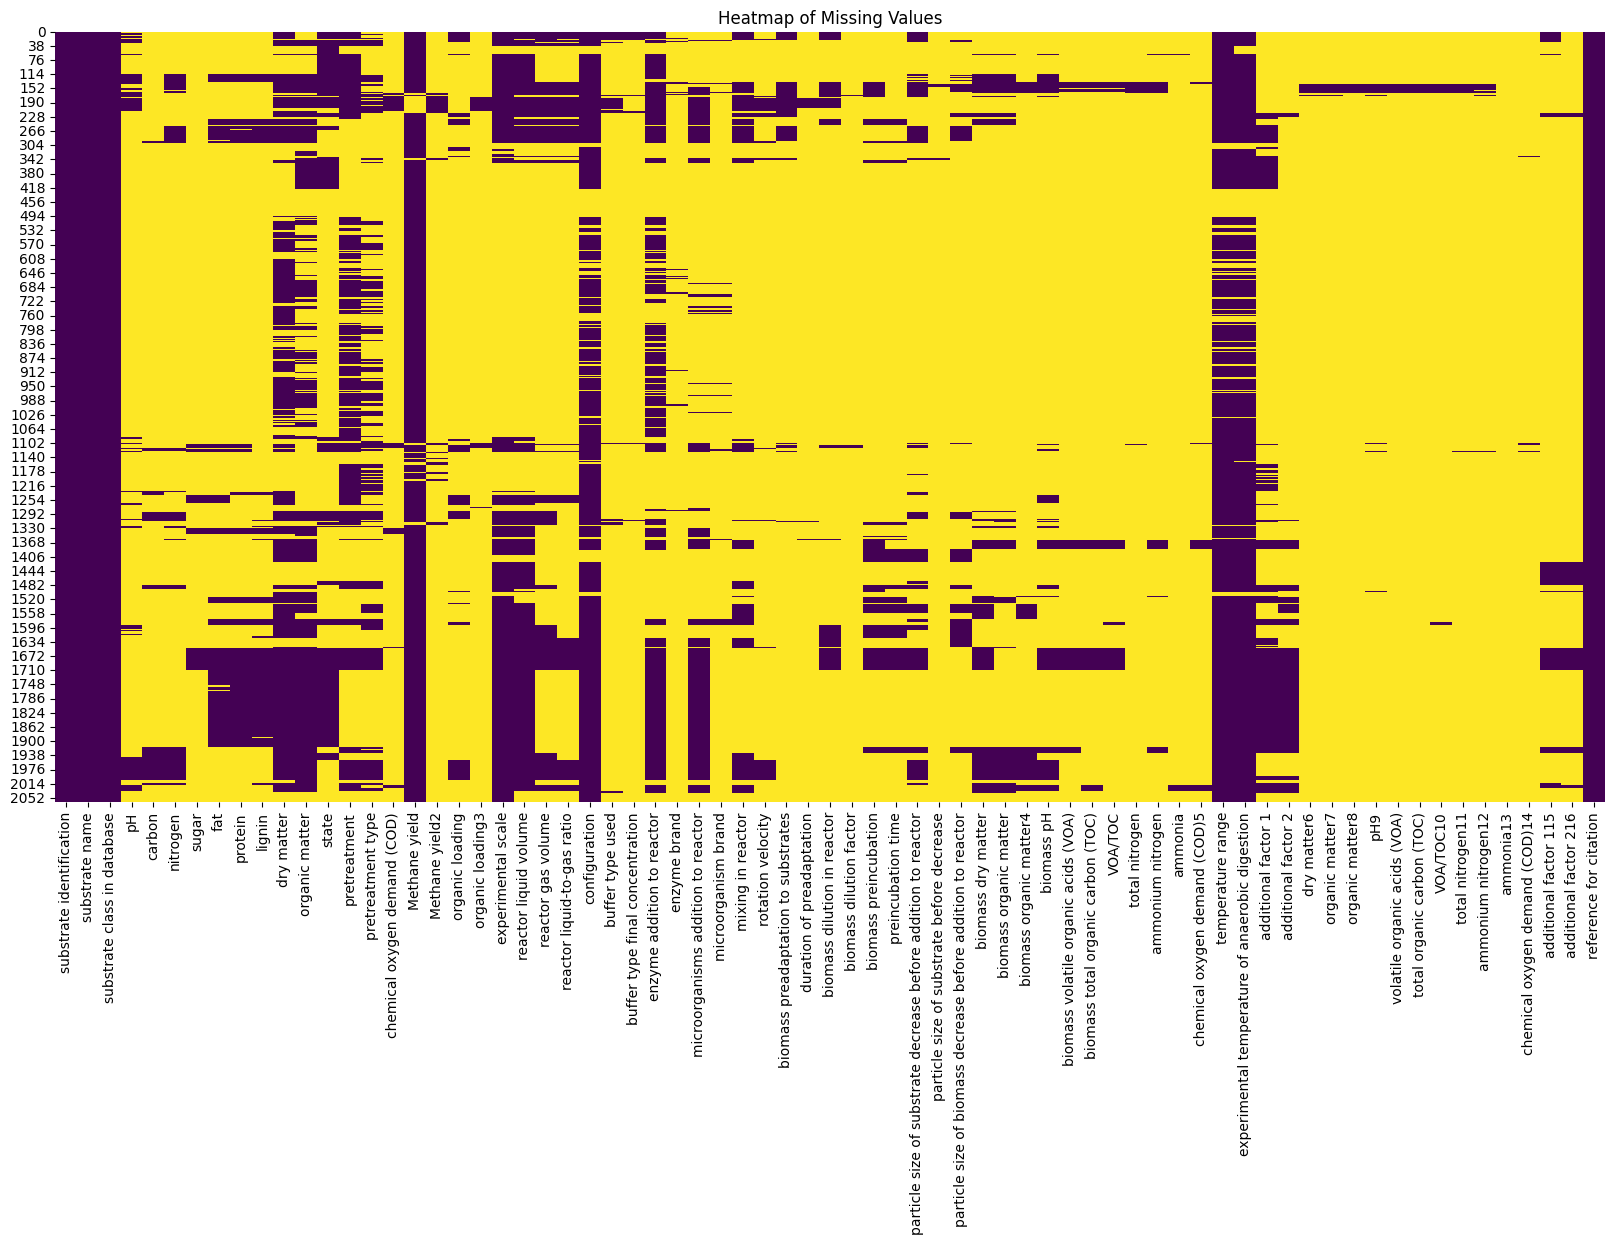

In [ ]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

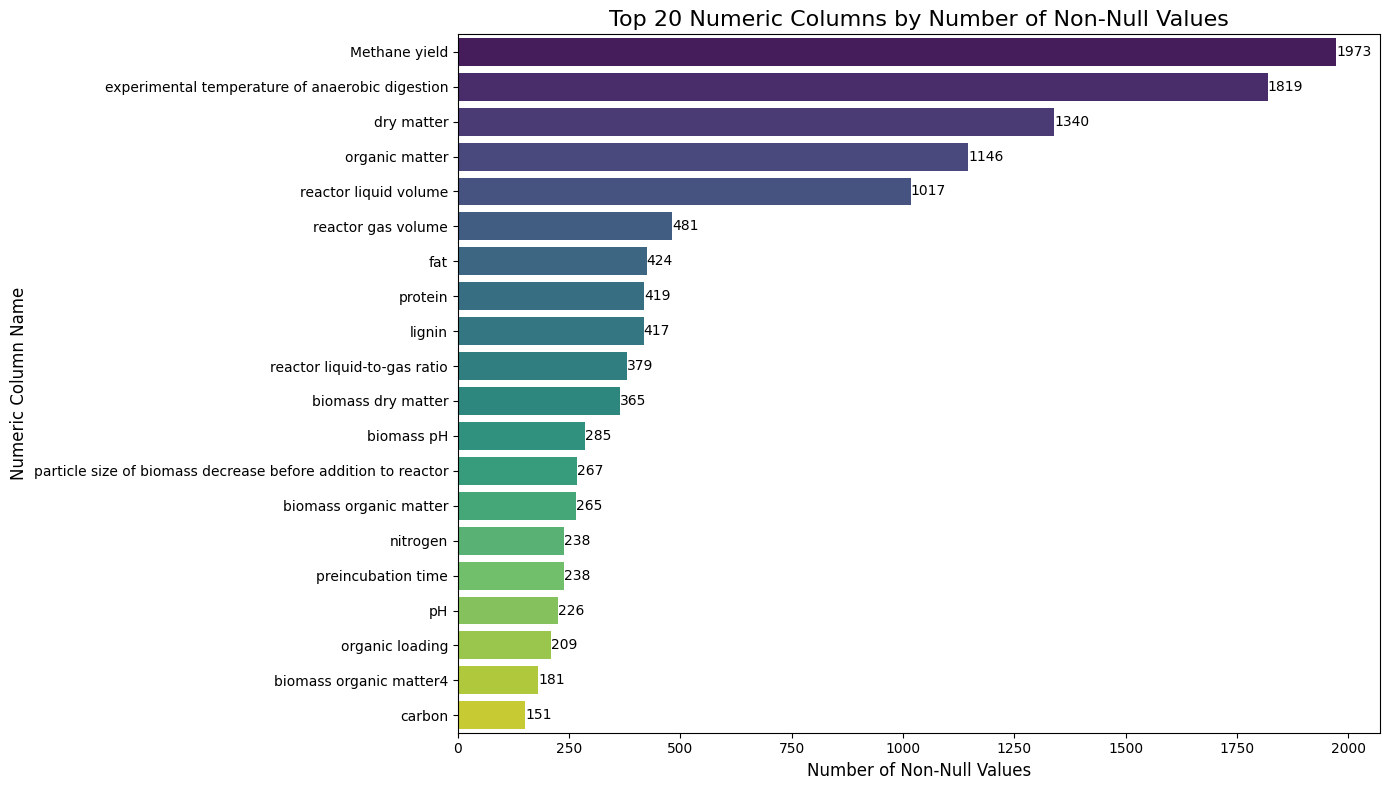

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Calculate the number of non-null values for each numeric column
non_null_counts_numeric = numeric_df.count()

# Sort in descending order and select the top 20 numeric columns
top_20_non_null_numeric = non_null_counts_numeric.sort_values(ascending=False).head(20)

# Create a bar plot for top 20 numeric columns
plt.figure(figsize=(14, 8))
ax = sns.barplot(x=top_20_non_null_numeric.values, y=top_20_non_null_numeric.index, hue=top_20_non_null_numeric.index, palette='viridis', legend=False)
plt.title('Top 20 Numeric Columns by Number of Non-Null Values', fontsize=16)
plt.xlabel('Number of Non-Null Values', fontsize=12)
plt.ylabel('Numeric Column Name', fontsize=12)

# Add count numbers on top of each bar
for index, value in enumerate(top_20_non_null_numeric.values):
    ax.text(value, index, str(value), color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

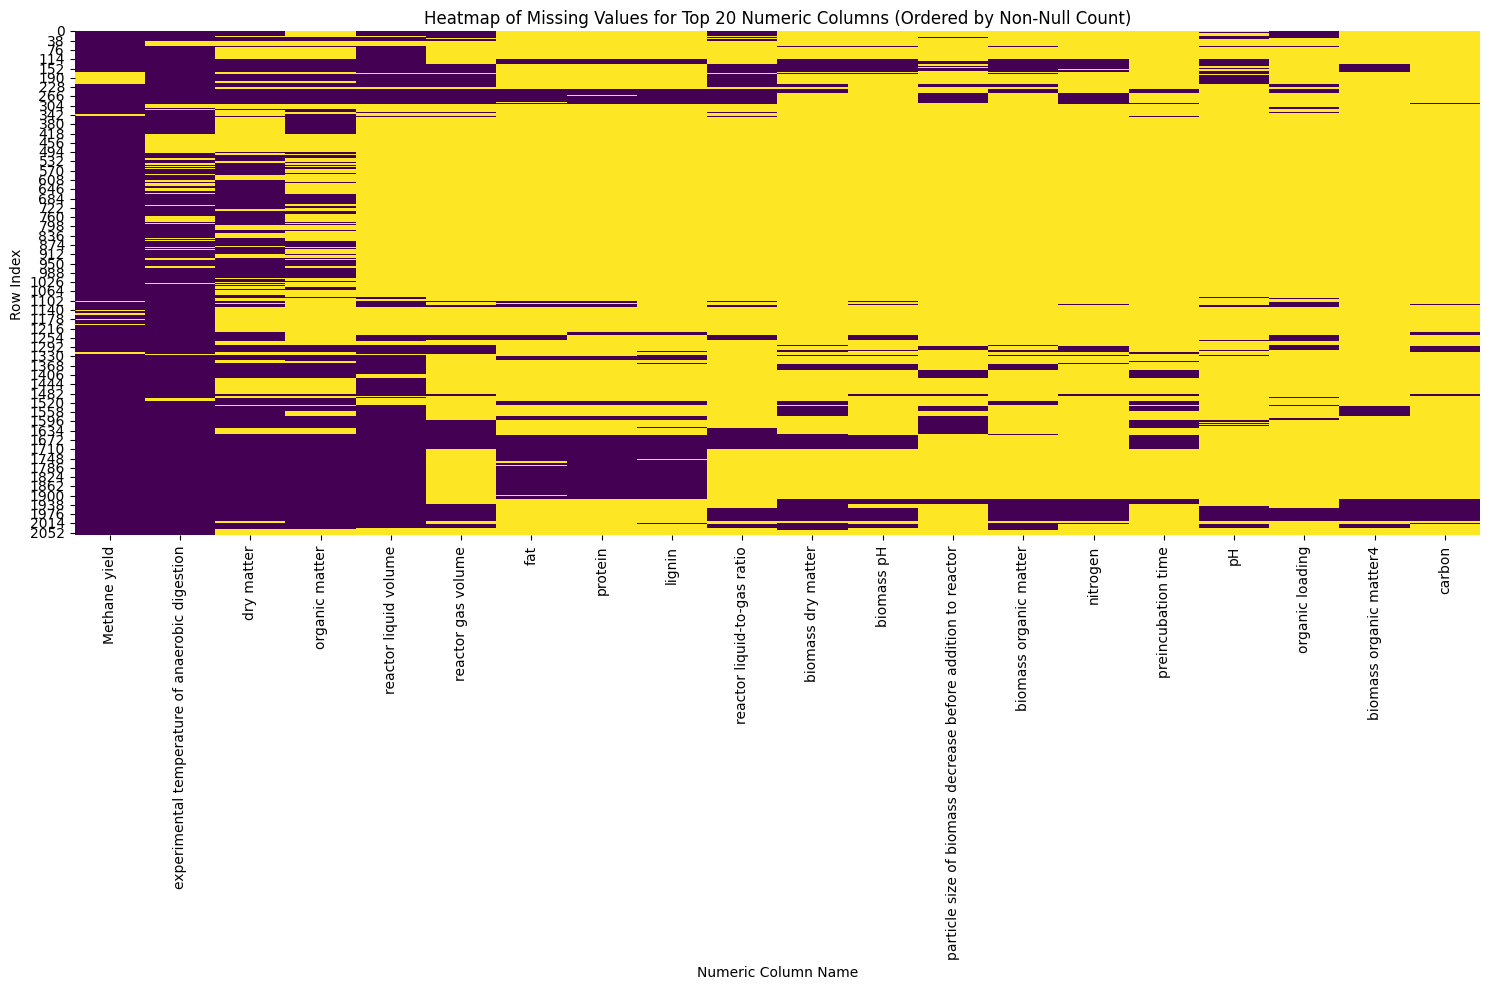

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the names of the top 20 numeric columns by non-null values
top_20_numeric_cols = top_20_non_null_numeric.index.tolist()

# Filter the DataFrame to include only these top 20 columns
df_top_20_numeric = df[top_20_numeric_cols]

# Recalculate null values for these columns to ensure proper ordering in the heatmap
# (though the filtering itself should maintain the order based on top_20_numeric_cols)
null_values_top_20 = df_top_20_numeric.isnull()

# Plotting the heatmap for these top 20 numeric columns
plt.figure(figsize=(15, 10))
sns.heatmap(null_values_top_20, cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values for Top 20 Numeric Columns (Ordered by Non-Null Count)')
plt.ylabel('Row Index')
plt.xlabel('Numeric Column Name')
plt.tight_layout()
plt.show()

Original DataFrame shape: (2062, 71)
Filtered DataFrame shape (non-null 'lignin'): (417, 71)


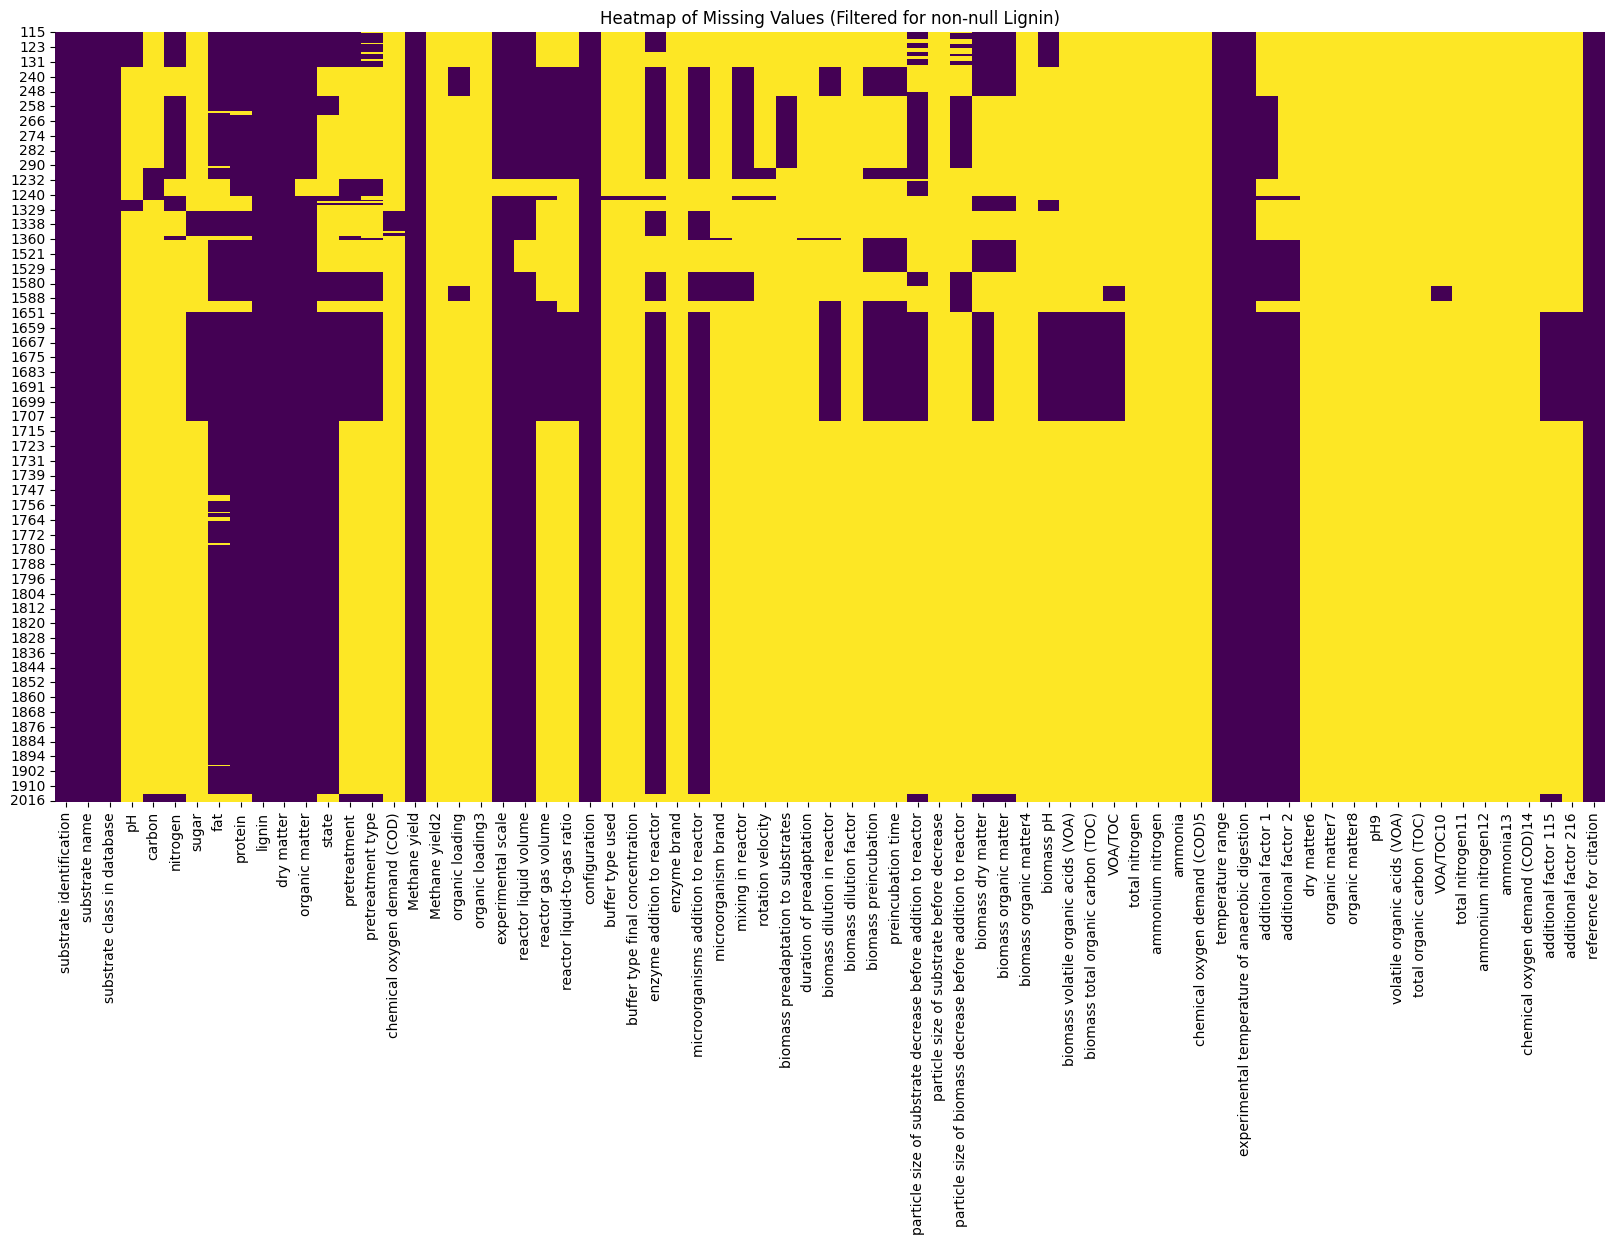

In [ ]:
# Filter the DataFrame to include only rows where 'lignin' is not null
df_filtered_lignin = df[df['lignin'].notna()]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape (non-null 'lignin'): {df_filtered_lignin.shape}")

# Plotting the heatmap for the filtered DataFrame
plt.figure(figsize=(20, 10))
sns.heatmap(df_filtered_lignin.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values (Filtered for non-null Lignin)')
plt.show()

In [ ]:
# Drop columns that are entirely null in the df_filtered_lignin DataFrame
df_lignin_non_empty_cols = df_filtered_lignin.dropna(axis=1, how='all')

print(f"Shape of DataFrame filtered for non-null 'lignin' and non-empty columns: {df_lignin_non_empty_cols.shape}")
print(df_lignin_non_empty_cols.info())

Shape of DataFrame filtered for non-null 'lignin' and non-empty columns: (417, 51)
<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 115 to 2016
Data columns (total 51 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   substrate identification                                        417 non-null    object 
 1   substrate name                                                  417 non-null    object 
 2   substrate class in database                                     417 non-null    object 
 3   pH                                                              25 non-null     float64
 4   carbon                                                          21 non-null     float64
 5   nitrogen                                                        78 non-null     float64
 6   sugar                                                           7

In [ ]:
# Calculate the number of non-null values in the 'fat' column from the df_lignin_non_empty_cols DataFrame
fat_non_null_count = df_lignin_non_empty_cols['fat'].count()

# Get non-null counts for all columns in the df_lignin_non_empty_cols DataFrame
non_null_counts_filtered = df_lignin_non_empty_cols.count()

# Identify columns to keep (non-null count >= fat_non_null_count)
columns_to_keep = non_null_counts_filtered[non_null_counts_filtered >= fat_non_null_count].index.tolist()

# Create a new DataFrame with only the selected columns
df_fat_column_cleaned = df_lignin_non_empty_cols[columns_to_keep]

print(f"Shape of DataFrame after removing columns with less non-null values than 'fat': {df_fat_column_cleaned.shape}")
print(df_fat_column_cleaned.info())

Shape of DataFrame after removing columns with less non-null values than 'fat': (417, 15)
<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 115 to 2016
Data columns (total 15 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   substrate identification                         417 non-null    object 
 1   substrate name                                   417 non-null    object 
 2   substrate class in database                      417 non-null    object 
 3   fat                                              378 non-null    float64
 4   protein                                          395 non-null    float64
 5   lignin                                           417 non-null    float64
 6   dry matter                                       417 non-null    float64
 7   organic matter                                   408 non-null    float64
 8   Methane yield         

Shape of DataFrame after filtering (including nitrogen and non-null fat): (378, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 378 entries, 115 to 1914
Data columns (total 16 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   substrate identification                         378 non-null    object 
 1   substrate name                                   378 non-null    object 
 2   substrate class in database                      378 non-null    object 
 3   fat                                              378 non-null    float64
 4   protein                                          377 non-null    float64
 5   lignin                                           378 non-null    float64
 6   dry matter                                       378 non-null    float64
 7   organic matter                                   378 non-null    float64
 8   Methane yield               

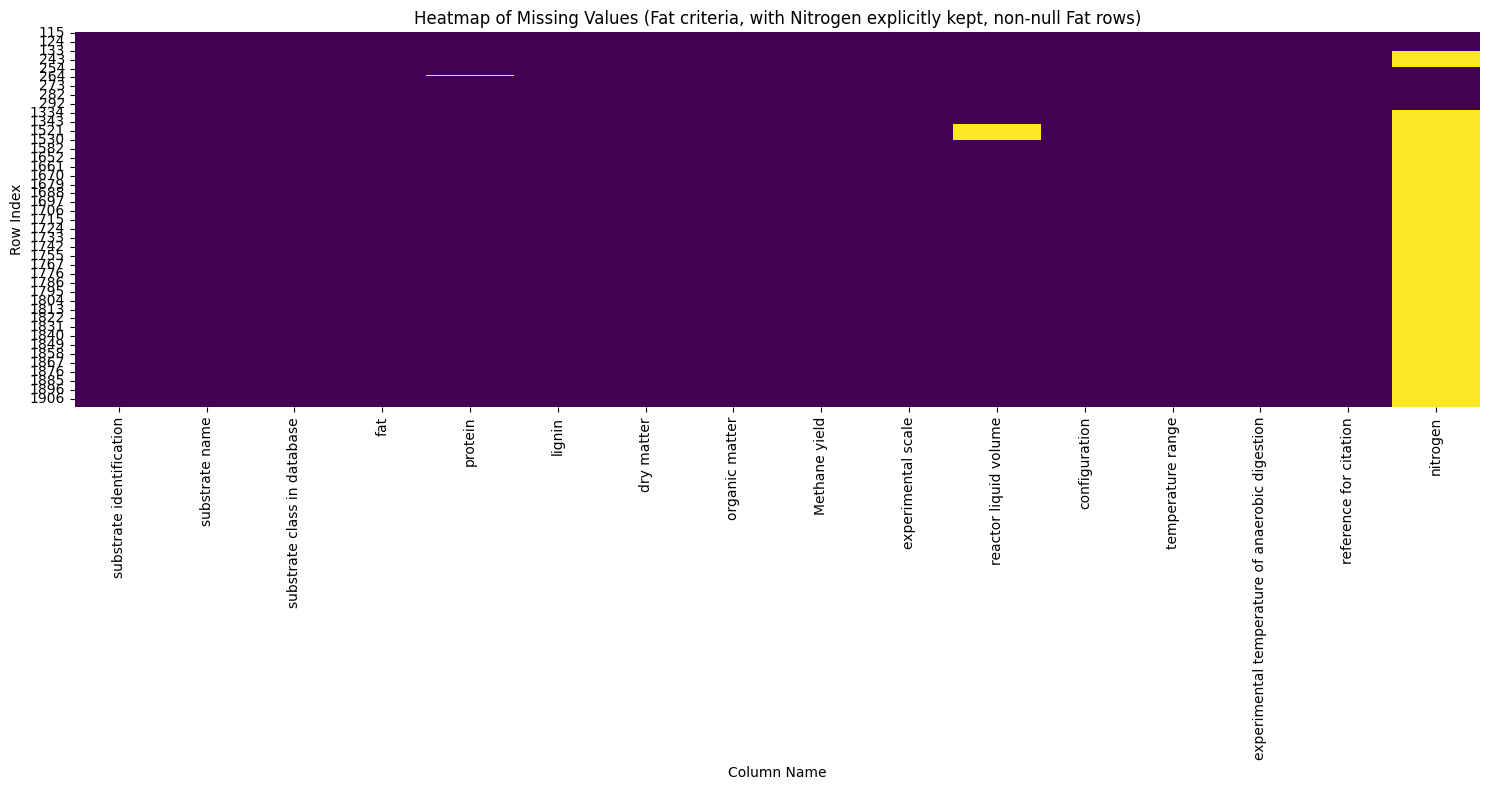

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-define df_filtered_lignin (from previous steps, to ensure availability)
df_filtered_lignin = df[df['lignin'].notna()]

# Re-define df_lignin_non_empty_cols (from previous steps, to ensure availability)
df_lignin_non_empty_cols = df_filtered_lignin.dropna(axis=1, how='all')

# Calculate the number of non-null values in the 'fat' column from df_lignin_non_empty_cols
fat_non_null_count = df_lignin_non_empty_cols['fat'].count()

# Get non-null counts for all columns in df_lignin_non_empty_cols
non_null_counts_lignin = df_lignin_non_empty_cols.count()

# Identify columns to keep: non-null count >= fat_non_null_count
columns_to_keep_refined = [
    col for col, count in non_null_counts_lignin.items()
    if count >= fat_non_null_count
]

# Explicitly add 'nitrogen' to the list of columns to keep if it's not already there
if 'nitrogen' not in columns_to_keep_refined:
    columns_to_keep_refined.append('nitrogen')

# Ensure 'nitrogen' is ordered correctly if you want it in a specific position, e.g., after 'carbon' or at the beginning
# For simplicity, we'll just add it to the end if not already present.

# Create an intermediate DataFrame with only the selected columns
df_intermediate = df_lignin_non_empty_cols[columns_to_keep_refined]

# Now remove all rows with null values in the 'fat' column from this intermediate DataFrame
df_final_cleaned = df_intermediate.dropna(subset=['fat'])

print(f"Shape of DataFrame after filtering (including nitrogen and non-null fat): {df_final_cleaned.shape}")
print(df_final_cleaned.info())

# Plot the heatmap for the resulting DataFrame
plt.figure(figsize=(15, 8))
sns.heatmap(df_final_cleaned.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values (Fat criteria, with Nitrogen explicitly kept, non-null Fat rows)')
plt.ylabel('Row Index')
plt.xlabel('Column Name')
plt.tight_layout()
plt.show()

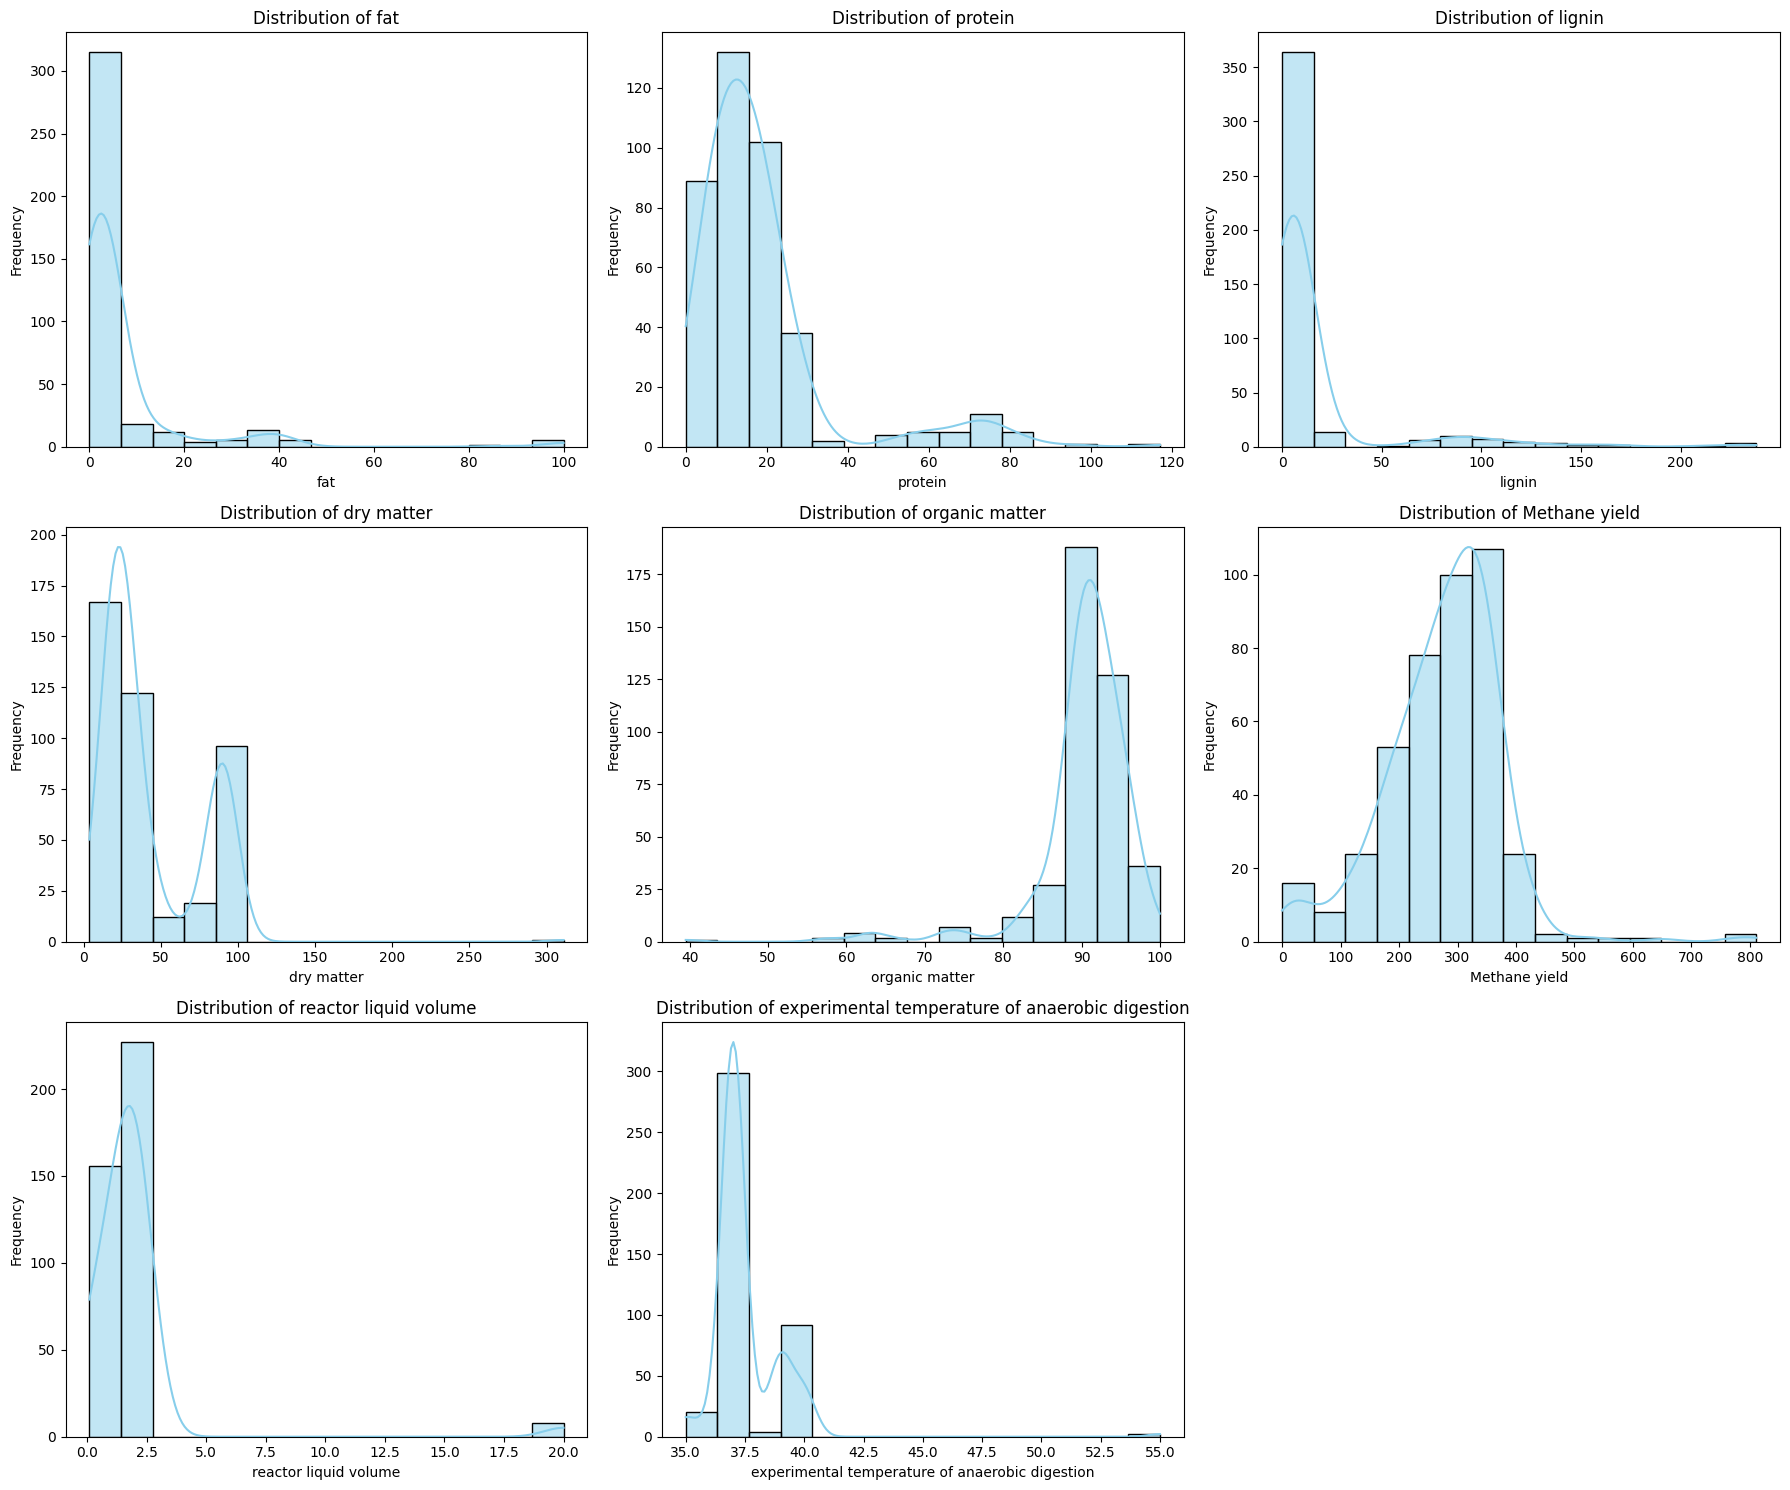

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Get the numeric columns from df_fat_column_cleaned
numeric_cols = df_fat_column_cleaned.select_dtypes(include=['number']).columns

# Determine the grid size for the subplots
num_cols = len(numeric_cols)
num_rows = math.ceil(num_cols / 3) # Arrange in 3 columns

plt.figure(figsize=(18, 5 * num_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(df_fat_column_cleaned[col].dropna(), kde=True, bins=15, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

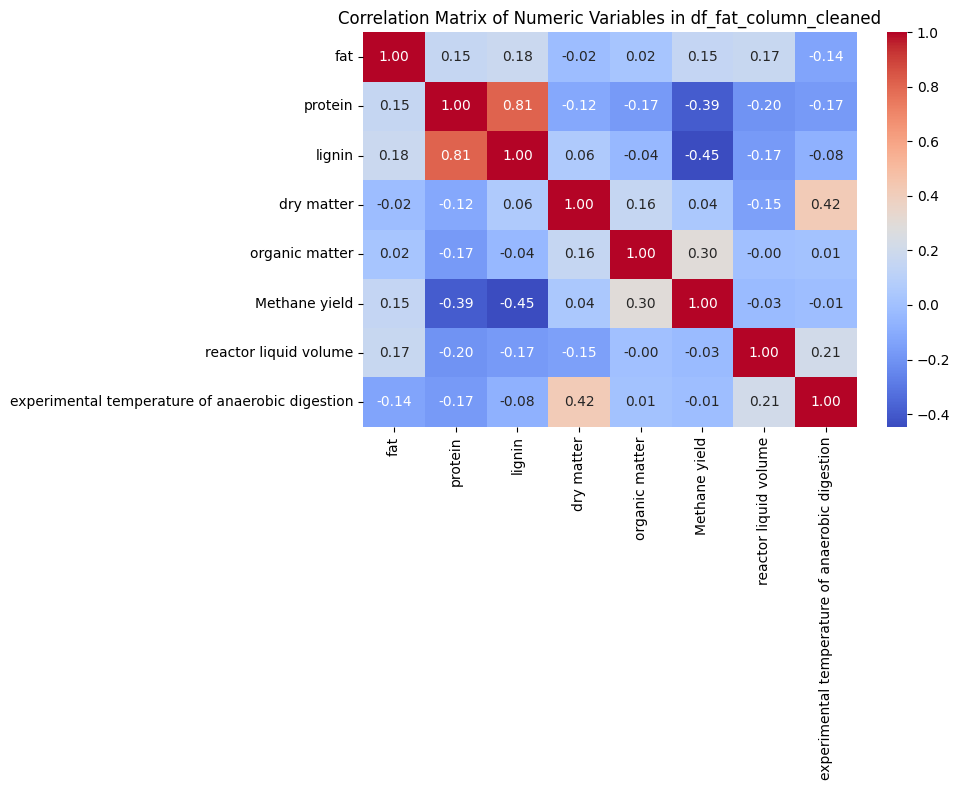

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns from df_fat_column_cleaned
numeric_cols_for_corr = df_fat_column_cleaned.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_cols_for_corr.corr()

# Plot the correlation matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables in df_fat_column_cleaned')
plt.tight_layout()
plt.show()

In [ ]:
df_final_cleaned = df_final_cleaned.drop('reactor liquid volume', axis=1)
print(df_final_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
Index: 378 entries, 115 to 1914
Data columns (total 15 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   substrate identification                         378 non-null    object 
 1   substrate name                                   378 non-null    object 
 2   substrate class in database                      378 non-null    object 
 3   fat                                              378 non-null    float64
 4   protein                                          377 non-null    float64
 5   lignin                                           378 non-null    float64
 6   dry matter                                       378 non-null    float64
 7   organic matter                                   378 non-null    float64
 8   Methane yield                                    378 non-null    float64
 9   experimental scale                

In [ ]:
missing_values_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AI book/Missing_values.csv')
print(missing_values_df.head())

      substrate name   dry matter  organic matter
0    Raw dairy manure       12.40            0.82
1         Cheese whey        7.14            0.84
2         Plain pasta       42.26            0.97
3          Meat pasta       38.18            0.89
4  Used vegetable oil       99.10            1.00


In [ ]:
df_final_cleaned.columns = df_final_cleaned.columns.str.strip()
missing_values_df.columns = missing_values_df.columns.str.strip()

merged_df = df_final_cleaned.merge(
    missing_values_df[['substrate name', 'dry matter']],
    on='substrate name',
    how='left',
    suffixes=('_original', '_new')
)

merged_df['dry matter'] = merged_df['dry matter_original'].fillna(merged_df['dry matter_new'])
df_final_cleaned = merged_df.drop(columns=['dry matter_original', 'dry matter_new'])

print(f"Number of missing 'dry matter' values after merge: {df_final_cleaned['dry matter'].isnull().sum()}")
print(df_final_cleaned.info())

Number of missing 'dry matter' values after merge: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 15 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   substrate identification                         378 non-null    object 
 1   substrate name                                   378 non-null    object 
 2   substrate class in database                      378 non-null    object 
 3   fat                                              378 non-null    float64
 4   protein                                          377 non-null    float64
 5   lignin                                           378 non-null    float64
 6   organic matter                                   378 non-null    float64
 7   Methane yield                                    378 non-null    float64
 8   experimental scale                               378 non-

Identify the row where 'protein' is null, calculate the 'protein' value by multiplying 'nitrogen' by 6.25 for that specific row, and then fill the missing value. Finally, print the updated info for the 'protein' column and the row where the value was imputed to confirm the change.



In [ ]:
missing_protein_row_index = df_final_cleaned[df_final_cleaned['protein'].isnull()].index

if not missing_protein_row_index.empty:
    index_to_fill = missing_protein_row_index[0]
    nitrogen_value = df_final_cleaned.loc[index_to_fill, 'nitrogen']

    if pd.notna(nitrogen_value):
        calculated_protein = nitrogen_value * 6.25
        df_final_cleaned.loc[index_to_fill, 'protein'] = calculated_protein
        print(f"Filled missing 'protein' at index {index_to_fill} with calculated value: {calculated_protein}")
    else:
        print(f"Cannot calculate 'protein' for index {index_to_fill} as 'nitrogen' is also missing.")
else:
    print("No missing 'protein' values found.")

print(df_final_cleaned.info())

Filled missing 'protein' at index 43 with calculated value: 4.4375
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 15 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   substrate identification                         378 non-null    object 
 1   substrate name                                   378 non-null    object 
 2   substrate class in database                      378 non-null    object 
 3   fat                                              378 non-null    float64
 4   protein                                          378 non-null    float64
 5   lignin                                           378 non-null    float64
 6   organic matter                                   378 non-null    float64
 7   Methane yield                                    378 non-null    float64
 8   experimental scale                         

In [ ]:
df_final_cleaned = df_final_cleaned.drop('nitrogen', axis=1)
print(df_final_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 14 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   substrate identification                         378 non-null    object 
 1   substrate name                                   378 non-null    object 
 2   substrate class in database                      378 non-null    object 
 3   fat                                              378 non-null    float64
 4   protein                                          378 non-null    float64
 5   lignin                                           378 non-null    float64
 6   organic matter                                   378 non-null    float64
 7   Methane yield                                    378 non-null    float64
 8   experimental scale                               378 non-null    object 
 9   configuration                   

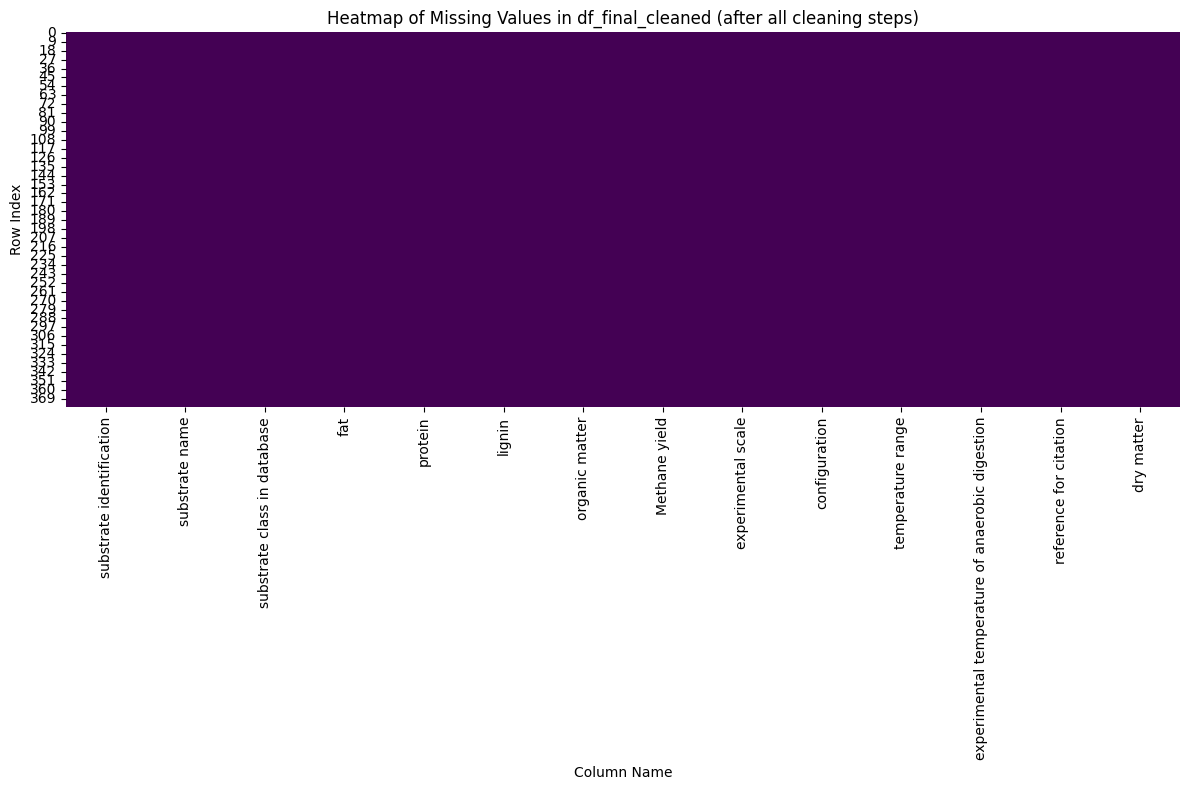

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_final_cleaned.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values in df_final_cleaned (after all cleaning steps)')
plt.xlabel('Column Name')
plt.ylabel('Row Index')
plt.tight_layout()
plt.show()

In [ ]:
df_final_cleaned

,substrate identification,substrate name,substrate class in database,fat,protein,lignin,organic matter,Methane yield,experimental scale,configuration,temperature range,experimental temperature of anaerobic digestion,reference for citation,dry matter
0,Straw,Barley Straw,agricultural,0.80,6.20,9.60,94.30,240.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.50
1,Straw,Barley Straw,agricultural,0.80,6.20,9.60,94.30,286.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.50
2,Straw,Barley Straw,agricultural,0.80,6.20,9.60,94.30,339.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.50
3,Straw,Barley Straw,agricultural,0.80,6.20,9.60,94.30,370.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.50
4,Straw,Barley Straw,agricultural,0.50,5.20,10.00,94.60,340.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,16.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,fibers,Mix fibers (Wheat; Camelina) fresh,agricultural,2.53,14.40,6.70,87.18,278.88,laboratory,batch,mesophilic,37.0,https://mediatum.ub.tum.de/doc/631394/631394.pdf,31.89
374,fibers,Mix fibers (Pea; Camelina) silage,agricultural,1.90,14.80,5.40,91.79,269.59,laboratory,batch,mesophilic,37.0,https://mediatum.ub.tum.de/doc/631394/631394.pdf,30.29
375,fibers,Mix fibers (Barley; Camelina) silage,agricultural,2.40,8.69,5.34,92.16,317.63,laboratory,batch,mesophilic,37.0,https://mediatum.ub.tum.de/doc/631394/631394.pdf,35.09
376,humulus,Humulus fresh,agricultural,1.96,16.60,10.90,89.87,141.33,laboratory,batch,mesophilic,37.0,https://mediatum.ub.tum.de/doc/631394/631394.pdf,31.10


In [ ]:
df_final_cleaned.describe()

,fat,protein,lignin,organic matter,Methane yield,experimental temperature of anaerobic digestion,dry matter
count,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000
mean,6.975741,18.315549,15.976349,90.567869,285.146942,37.452381,41.482989
std,14.523878,17.642361,33.321838,5.823386,89.560681,1.101774,29.362655
min,0.000000,0.000000,0.000000,39.490000,17.017000,35.000000,3.700000
25%,1.820000,8.092500,3.500000,89.247500,229.320000,37.000000,20.682500
50%,2.700000,14.225000,5.875000,91.140000,293.190000,37.000000,26.455000
75%,3.707500,20.275000,8.675000,93.642256,340.722500,37.000000,79.500000
max,100.000000,117.000000,238.000000,100.000000,811.000000,40.000000,99.700000


In [ ]:
df_final_cleaned.loc[df_final_cleaned['lignin'] > 35, 'lignin'] = df_final_cleaned.loc[df_final_cleaned['lignin'] > 35, 'lignin'] / 10
print("DataFrame after filtering and dividing 'lignin' values:")
display(df_final_cleaned)

DataFrame after filtering and dividing 'lignin' values:


,substrate identification,substrate name,substrate class in database,fat,protein,lignin,organic matter,Methane yield,experimental scale,configuration,temperature range,experimental temperature of anaerobic digestion,reference for citation,dry matter
0,Straw,Barley Straw,agricultural,0.80,6.20,9.60,94.30,240.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.50
1,Straw,Barley Straw,agricultural,0.80,6.20,9.60,94.30,286.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.50
2,Straw,Barley Straw,agricultural,0.80,6.20,9.60,94.30,339.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.50
3,Straw,Barley Straw,agricultural,0.80,6.20,9.60,94.30,370.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.50
4,Straw,Barley Straw,agricultural,0.50,5.20,10.00,94.60,340.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,16.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,fibers,Mix fibers (Wheat; Camelina) fresh,agricultural,2.53,14.40,6.70,87.18,278.88,laboratory,batch,mesophilic,37.0,https://mediatum.ub.tum.de/doc/631394/631394.pdf,31.89
374,fibers,Mix fibers (Pea; Camelina) silage,agricultural,1.90,14.80,5.40,91.79,269.59,laboratory,batch,mesophilic,37.0,https://mediatum.ub.tum.de/doc/631394/631394.pdf,30.29
375,fibers,Mix fibers (Barley; Camelina) silage,agricultural,2.40,8.69,5.34,92.16,317.63,laboratory,batch,mesophilic,37.0,https://mediatum.ub.tum.de/doc/631394/631394.pdf,35.09
376,humulus,Humulus fresh,agricultural,1.96,16.60,10.90,89.87,141.33,laboratory,batch,mesophilic,37.0,https://mediatum.ub.tum.de/doc/631394/631394.pdf,31.10


In [ ]:
df_final_cleaned.describe()

,fat,protein,lignin,organic matter,Methane yield,experimental temperature of anaerobic digestion,dry matter
count,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000
mean,6.975741,18.315549,6.338254,90.567869,285.146942,37.452381,41.482989
std,14.523878,17.642361,4.144800,5.823386,89.560681,1.101774,29.362655
min,0.000000,0.000000,0.000000,39.490000,17.017000,35.000000,3.700000
25%,1.820000,8.092500,3.500000,89.247500,229.320000,37.000000,20.682500
50%,2.700000,14.225000,5.815000,91.140000,293.190000,37.000000,26.455000
75%,3.707500,20.275000,8.300000,93.642256,340.722500,37.000000,79.500000
max,100.000000,117.000000,28.100000,100.000000,811.000000,40.000000,99.700000


In [ ]:
print(df_final_cleaned['reference for citation'].unique())

['Menardo. S.. Airoldi. G.. Balsari. P. 2012. The effect of particle size and thermal pre-treatment on the methane yield of four agricultural by-products. Bioresource Technology. 104(0). 708-714.'
 'Li, Y., Zhang, R., Liu, G., Chen, C., He, Y., Liu, X. 2013. Comparison of methane production potential, biodegradability, and kinetics of different organic substrates. Bioresource Technology, 149(0), 565-569.'
 'M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., Jungbluth, T., (2013). Investigation of the Methane Potential of Horse Manure. Agricultural Engineering International: CIGR Journal, Vol. 15, No. 2'
 'Ge, X., Matsumoto, T., Keith, L., Li, Y. 2014. Biogas energy production from tropical biomass wastes by anaerobic digestion. Bioresource Technology, 169(0), 38-44.'
 'Labatut, R.A., Angenent, L.T., Scott, N.R., 2011. Biochemical methane potential and biodegradability of complex organic substrates. Bioresour. Technol. 102, 2255ÔÇô2264. doi:10.1016/J.BIORTECH.2010.10.015'
 'Labatut, R.A., An

In [ ]:
filtered_df_citation = df_final_cleaned[df_final_cleaned['reference for citation'].str.contains('Investigation of the Methane Potential of Horse Manure', na=False)]
print("DataFrame filtered by citation:")
display(filtered_df_citation)

DataFrame filtered by citation:


,substrate identification,substrate name,substrate class in database,fat,protein,lignin,organic matter,Methane yield,experimental scale,configuration,temperature range,experimental temperature of anaerobic digestion,reference for citation,dry matter
35,Straw,Straw - horse bedding material,agricultural,9.1,54.0000,8.8,92.466675,214.214,laboratory,batch,mesophilic,37.0,"M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., ...",81.77
36,Straw,Straw - horse bedding material,agricultural,12.0,25.0000,6.7,93.776536,237.237,laboratory,batch,mesophilic,37.0,"M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., ...",89.50
37,Straw,Straw - horse bedding material,agricultural,12.0,29.0000,9.6,94.368996,203.203,laboratory,batch,mesophilic,37.0,"M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., ...",90.57
38,Straw,Straw - horse bedding material,agricultural,10.0,26.0000,7.4,93.559024,183.183,laboratory,batch,mesophilic,37.0,"M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., ...",90.98
39,Straw,Straw - horse bedding material,agricultural,12.0,52.0000,7.5,94.397562,200.200,laboratory,batch,mesophilic,37.0,"M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., ...",85.32
40,Straw,Straw-pellets as horse bedding material,agricultural,8.5,36.0000,5.6,94.568477,247.247,laboratory,batch,mesophilic,37.0,"M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., ...",90.03
41,Straw,Straw/Flax as horse bedding material,agricultural,11.0,65.0000,11.9,93.217774,156.156,laboratory,batch,mesophilic,37.0,"M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., ...",72.69
42,Straw,Flax as horse bedding material,agricultural,7.7,27.0000,21.0,97.836567,67.067,laboratory,batch,mesophilic,37.0,"M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., ...",85.05
43,Wood,Sawdust as horse bedding material,agricultural,8.7,4.4375,23.8,99.639423,17.017,laboratory,batch,mesophilic,37.0,"M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., ...",83.20
44,Manure,horse dung,agricultural,29.0,74.0000,10.0,88.443295,176.000,laboratory,batch,mesophilic,37.0,"M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., ...",23.19


In [ ]:
filtered_df_citation.loc[:, 'protein'] = filtered_df_citation['protein'] / 10

df_final_cleaned.loc[filtered_df_citation.index, 'protein'] = filtered_df_citation['protein']

print("DataFrame after dividing 'protein' values for filtered rows:")
display(df_final_cleaned)

DataFrame after dividing 'protein' values for filtered rows:


,substrate identification,substrate name,substrate class in database,fat,protein,lignin,organic matter,Methane yield,experimental scale,configuration,temperature range,experimental temperature of anaerobic digestion,reference for citation,dry matter
0,Straw,Barley Straw,agricultural,0.80,6.20,9.60,94.30,240.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.50
1,Straw,Barley Straw,agricultural,0.80,6.20,9.60,94.30,286.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.50
2,Straw,Barley Straw,agricultural,0.80,6.20,9.60,94.30,339.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.50
3,Straw,Barley Straw,agricultural,0.80,6.20,9.60,94.30,370.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.50
4,Straw,Barley Straw,agricultural,0.50,5.20,10.00,94.60,340.00,laboratory,batch,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,16.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,fibers,Mix fibers (Wheat; Camelina) fresh,agricultural,2.53,14.40,6.70,87.18,278.88,laboratory,batch,mesophilic,37.0,https://mediatum.ub.tum.de/doc/631394/631394.pdf,31.89
374,fibers,Mix fibers (Pea; Camelina) silage,agricultural,1.90,14.80,5.40,91.79,269.59,laboratory,batch,mesophilic,37.0,https://mediatum.ub.tum.de/doc/631394/631394.pdf,30.29
375,fibers,Mix fibers (Barley; Camelina) silage,agricultural,2.40,8.69,5.34,92.16,317.63,laboratory,batch,mesophilic,37.0,https://mediatum.ub.tum.de/doc/631394/631394.pdf,35.09
376,humulus,Humulus fresh,agricultural,1.96,16.60,10.90,89.87,141.33,laboratory,batch,mesophilic,37.0,https://mediatum.ub.tum.de/doc/631394/631394.pdf,31.10


In [ ]:
df_final_cleaned.describe()

,fat,protein,lignin,organic matter,Methane yield,experimental temperature of anaerobic digestion,dry matter
count,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000
mean,6.975741,12.709745,6.338254,90.567869,285.146942,37.452381,41.482989
std,14.523878,6.908773,4.144800,5.823386,89.560681,1.101774,29.362655
min,0.000000,0.000000,0.000000,39.490000,17.017000,35.000000,3.700000
25%,1.820000,7.200000,3.500000,89.247500,229.320000,37.000000,20.682500
50%,2.700000,12.245000,5.815000,91.140000,293.190000,37.000000,26.455000
75%,3.707500,17.682500,8.300000,93.642256,340.722500,37.000000,79.500000
max,100.000000,31.030000,28.100000,100.000000,811.000000,40.000000,99.700000


In [ ]:
df_encoded = pd.get_dummies(df_final_cleaned, columns=['experimental scale', 'configuration'], drop_first=True)
print("DataFrame after one-hot encoding:")
display(df_encoded.head())

DataFrame after one-hot encoding:


,substrate identification,substrate name,substrate class in database,fat,protein,lignin,organic matter,Methane yield,temperature range,experimental temperature of anaerobic digestion,reference for citation,dry matter,experimental scale_pilot,configuration_semicontinuous
0,Straw,Barley Straw,agricultural,0.8,6.2,9.6,94.3,240.0,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.5,False,False
1,Straw,Barley Straw,agricultural,0.8,6.2,9.6,94.3,286.0,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.5,False,False
2,Straw,Barley Straw,agricultural,0.8,6.2,9.6,94.3,339.0,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.5,False,False
3,Straw,Barley Straw,agricultural,0.8,6.2,9.6,94.3,370.0,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,90.5,False,False
4,Straw,Barley Straw,agricultural,0.5,5.2,10.0,94.6,340.0,mesophilic,40.0,Menardo. S.. Airoldi. G.. Balsari. P. 2012. Th...,16.9,False,False


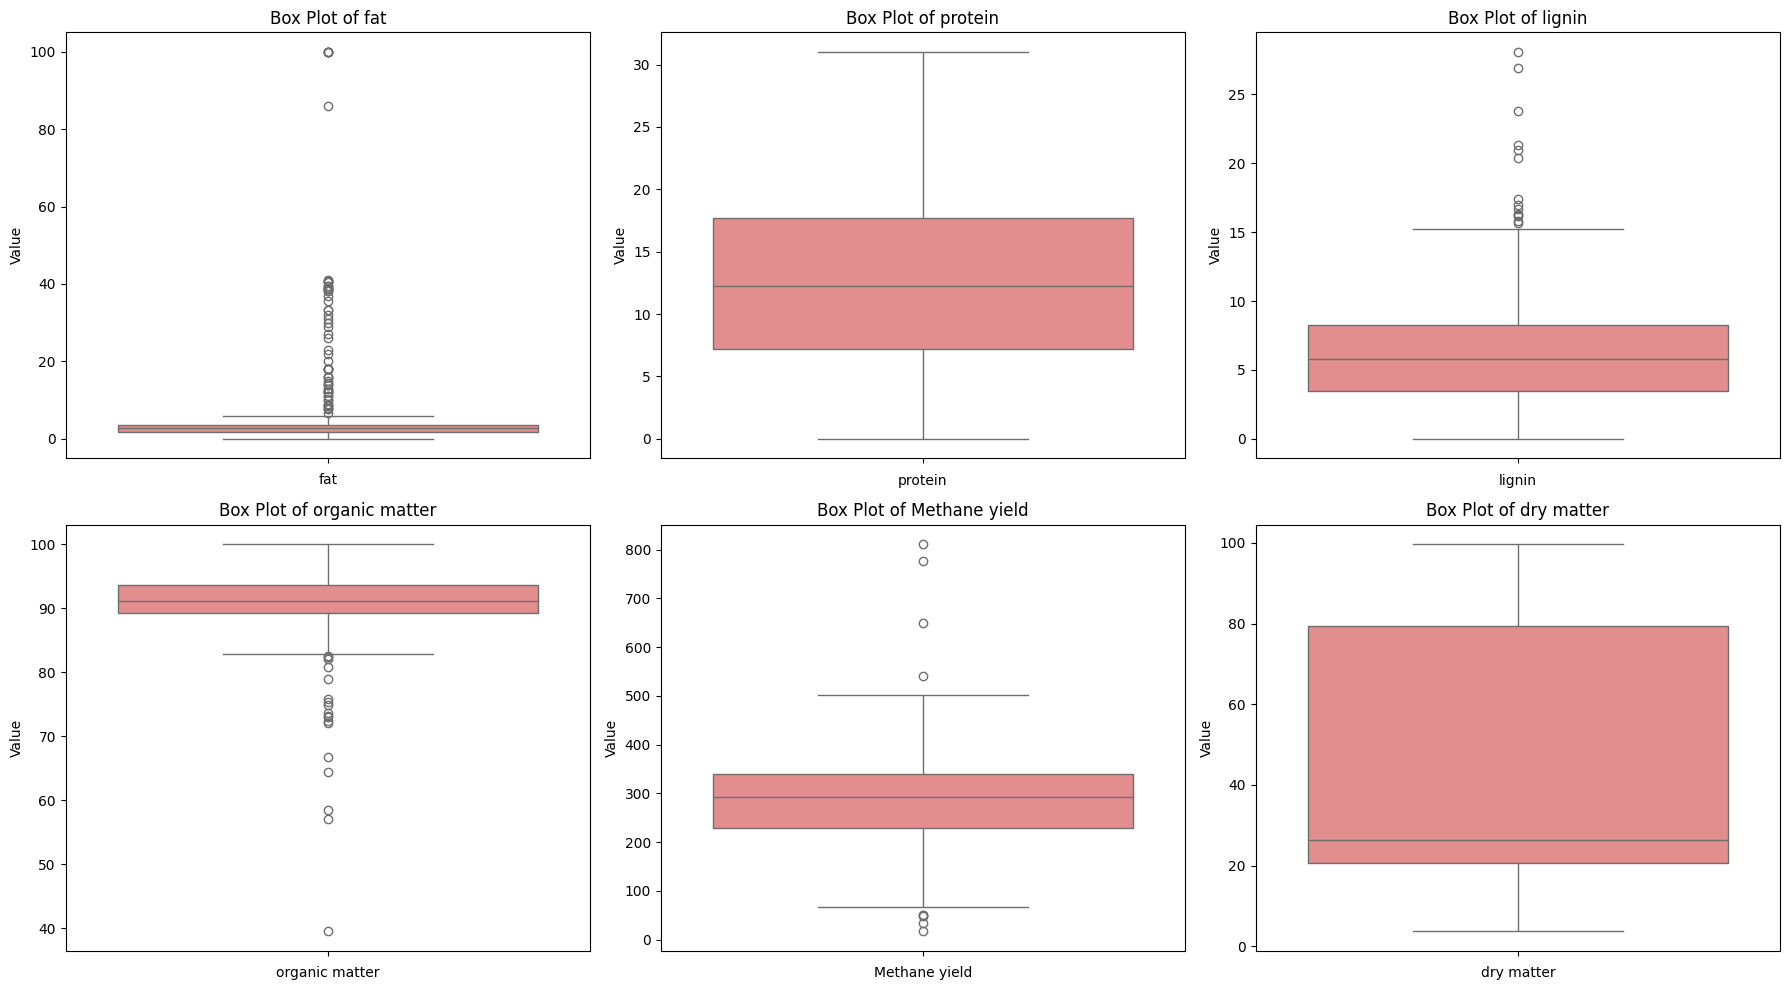

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Get the numeric columns from df_encoded
numeric_cols_encoded = df_encoded.select_dtypes(include=['number']).columns

# Exclude 'experimental temperature of anaerobic digestion'
numeric_cols_encoded = numeric_cols_encoded.drop('experimental temperature of anaerobic digestion')

# Determine the grid size for the subplots
num_cols_per_row = 3
num_rows = math.ceil(len(numeric_cols_encoded) / num_cols_per_row)

plt.figure(figsize=(18, 5 * num_rows))

for i, col in enumerate(numeric_cols_encoded):
    plt.subplot(num_rows, num_cols_per_row, i + 1)
    sns.boxplot(y=df_encoded[col], color='lightcoral')
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

In [ ]:
df_encoded.to_csv('ADdata_encoded.csv', index=False)
print("DataFrame successfully saved")

DataFrame successfully saved


In [ ]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

# Select only numeric columns for LOF, excluding the experimental temperature
numeric_cols_for_lof = df_encoded.select_dtypes(include=np.number).columns.drop(
    ['experimental temperature of anaerobic digestion']
)

# Prepare the data for LOF
X = df_encoded[numeric_cols_for_lof]

# Handle potential NaN values by filling with the mean (or median) before LOF,
# although previous steps indicate no NaNs in these columns after cleaning.
# This is a safeguard.
X = X.fillna(X.mean())

# Initialize and fit the LOF model
# n_neighbors: number of neighbors to consider for the local density calculation
# contamination: proportion of outliers in the dataset. 'auto' tries to estimate it.
lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')

# Fit the model and predict outlier scores
# negative_outlier_factor_ are the LOF scores. Lower values indicate a higher likelihood of being an outlier.
df_encoded['lof_score'] = lof.fit_predict(X)
df_encoded['lof_negative_factor'] = lof.negative_outlier_factor_

# Identify outliers (typically samples with negative LOF score, or below a certain threshold)
# The 'contamination' parameter in LOF implicitly determines the threshold for 'is_outlier'
# A common way to identify significant outliers is to look at the lowest (most negative) LOF scores
outliers_lof = df_encoded[df_encoded['lof_score'] == -1].sort_values(by='lof_negative_factor')

print(f"Number of outliers detected by LOF: {len(outliers_lof)}")
print("Top 10 potential outliers based on LOF score (most negative scores):")
display(outliers_lof.head(10))

Number of outliers detected by LOF: 26
Top 10 potential outliers based on LOF score (most negative scores):


,substrate identification,substrate name,substrate class in database,fat,protein,lignin,organic matter,Methane yield,temperature range,experimental temperature of anaerobic digestion,reference for citation,dry matter,experimental scale_pilot,configuration_semicontinuous,lof_score,lof_negative_factor
28,FOG,Used vegetable oil,municipal,99.90,0.00000,0.00,99.900000,811.000,mesophilic,37.0,"Li, Y., Zhang, R., Liu, G., Chen, C., He, Y., ...",99.60,False,False,-1,-7.467718
27,FOG,Used animal oil,municipal,99.90,0.00000,0.00,99.900000,776.000,mesophilic,37.0,"Li, Y., Zhang, R., Liu, G., Chen, C., He, Y., ...",99.70,False,False,-1,-6.944993
82,Used vegetable oil,Used vegetable oil,OFMSW,100.00,0.00000,0.00,100.000000,648.500,mesophilic,35.0,"Labatut, R.A., Angenent, L.T., Scott, N.R., 20...",99.10,False,False,-1,-5.095919
25,OFMSW,Kitchen waste,municipal,35.50,16.00000,4.30,86.300000,541.000,mesophilic,37.0,"Li, Y., Zhang, R., Liu, G., Chen, C., He, Y., ...",26.30,False,False,-1,-3.277582
90,FOG,"Suspended fat, oil and grease (FOG)",municipal,100.00,0.00000,0.00,86.000000,402.300,mesophilic,35.0,"Labatut, R.A., Angenent, L.T., Scott, N.R., 20...",26.72,False,False,-1,-3.259730
91,FOG,"Settled fat, oil and grease (FOG)",municipal,100.00,0.00000,0.00,88.000000,413.400,mesophilic,35.0,"Labatut, R.A., Angenent, L.T., Scott, N.R., 20...",12.84,False,False,-1,-2.985676
83,Ice cream,Ice cream,industrial,38.60,8.30000,0.00,96.000000,502.300,mesophilic,35.0,"Labatut, R.A., Angenent, L.T., Scott, N.R., 20...",11.38,False,False,-1,-2.625117
43,Wood,Sawdust as horse bedding material,agricultural,8.70,0.44375,23.80,99.639423,17.017,mesophilic,37.0,"M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., ...",83.20,False,False,-1,-2.279438
103,slaughter house waste,fish slaughter waste,industrial,86.01,15.00000,1.08,97.470000,142.230,mesophilic,37.0,"Cu, T.T.T., Nguyen, T.X., Triolo, J.M., Peders...",60.00,False,False,-1,-2.184642
108,cassava,cassava residue,agricultural,0.80,2.90000,16.33,98.070000,33.460,mesophilic,37.0,"Cu, T.T.T., Nguyen, T.X., Triolo, J.M., Peders...",18.63,False,False,-1,-2.010939


In [ ]:
print("Outlier rows from df_encoded:")
display(outliers_lof)

Outlier rows from df_encoded:


,substrate identification,substrate name,substrate class in database,fat,protein,lignin,organic matter,Methane yield,temperature range,experimental temperature of anaerobic digestion,reference for citation,dry matter,experimental scale_pilot,configuration_semicontinuous,lof_score,lof_negative_factor
28,FOG,Used vegetable oil,municipal,99.90,0.00000,0.00,99.900000,811.000,mesophilic,37.0,"Li, Y., Zhang, R., Liu, G., Chen, C., He, Y., ...",99.60,False,False,-1,-7.467718
27,FOG,Used animal oil,municipal,99.90,0.00000,0.00,99.900000,776.000,mesophilic,37.0,"Li, Y., Zhang, R., Liu, G., Chen, C., He, Y., ...",99.70,False,False,-1,-6.944993
82,Used vegetable oil,Used vegetable oil,OFMSW,100.00,0.00000,0.00,100.000000,648.500,mesophilic,35.0,"Labatut, R.A., Angenent, L.T., Scott, N.R., 20...",99.10,False,False,-1,-5.095919
25,OFMSW,Kitchen waste,municipal,35.50,16.00000,4.30,86.300000,541.000,mesophilic,37.0,"Li, Y., Zhang, R., Liu, G., Chen, C., He, Y., ...",26.30,False,False,-1,-3.277582
90,FOG,"Suspended fat, oil and grease (FOG)",municipal,100.00,0.00000,0.00,86.000000,402.300,mesophilic,35.0,"Labatut, R.A., Angenent, L.T., Scott, N.R., 20...",26.72,False,False,-1,-3.259730
91,FOG,"Settled fat, oil and grease (FOG)",municipal,100.00,0.00000,0.00,88.000000,413.400,mesophilic,35.0,"Labatut, R.A., Angenent, L.T., Scott, N.R., 20...",12.84,False,False,-1,-2.985676
83,Ice cream,Ice cream,industrial,38.60,8.30000,0.00,96.000000,502.300,mesophilic,35.0,"Labatut, R.A., Angenent, L.T., Scott, N.R., 20...",11.38,False,False,-1,-2.625117
43,Wood,Sawdust as horse bedding material,agricultural,8.70,0.44375,23.80,99.639423,17.017,mesophilic,37.0,"M├Ânch-Tegeder, M., Lemmer, A., Oechsner, H., ...",83.20,False,False,-1,-2.279438
103,slaughter house waste,fish slaughter waste,industrial,86.01,15.00000,1.08,97.470000,142.230,mesophilic,37.0,"Cu, T.T.T., Nguyen, T.X., Triolo, J.M., Peders...",60.00,False,False,-1,-2.184642
108,cassava,cassava residue,agricultural,0.80,2.90000,16.33,98.070000,33.460,mesophilic,37.0,"Cu, T.T.T., Nguyen, T.X., Triolo, J.M., Peders...",18.63,False,False,-1,-2.010939


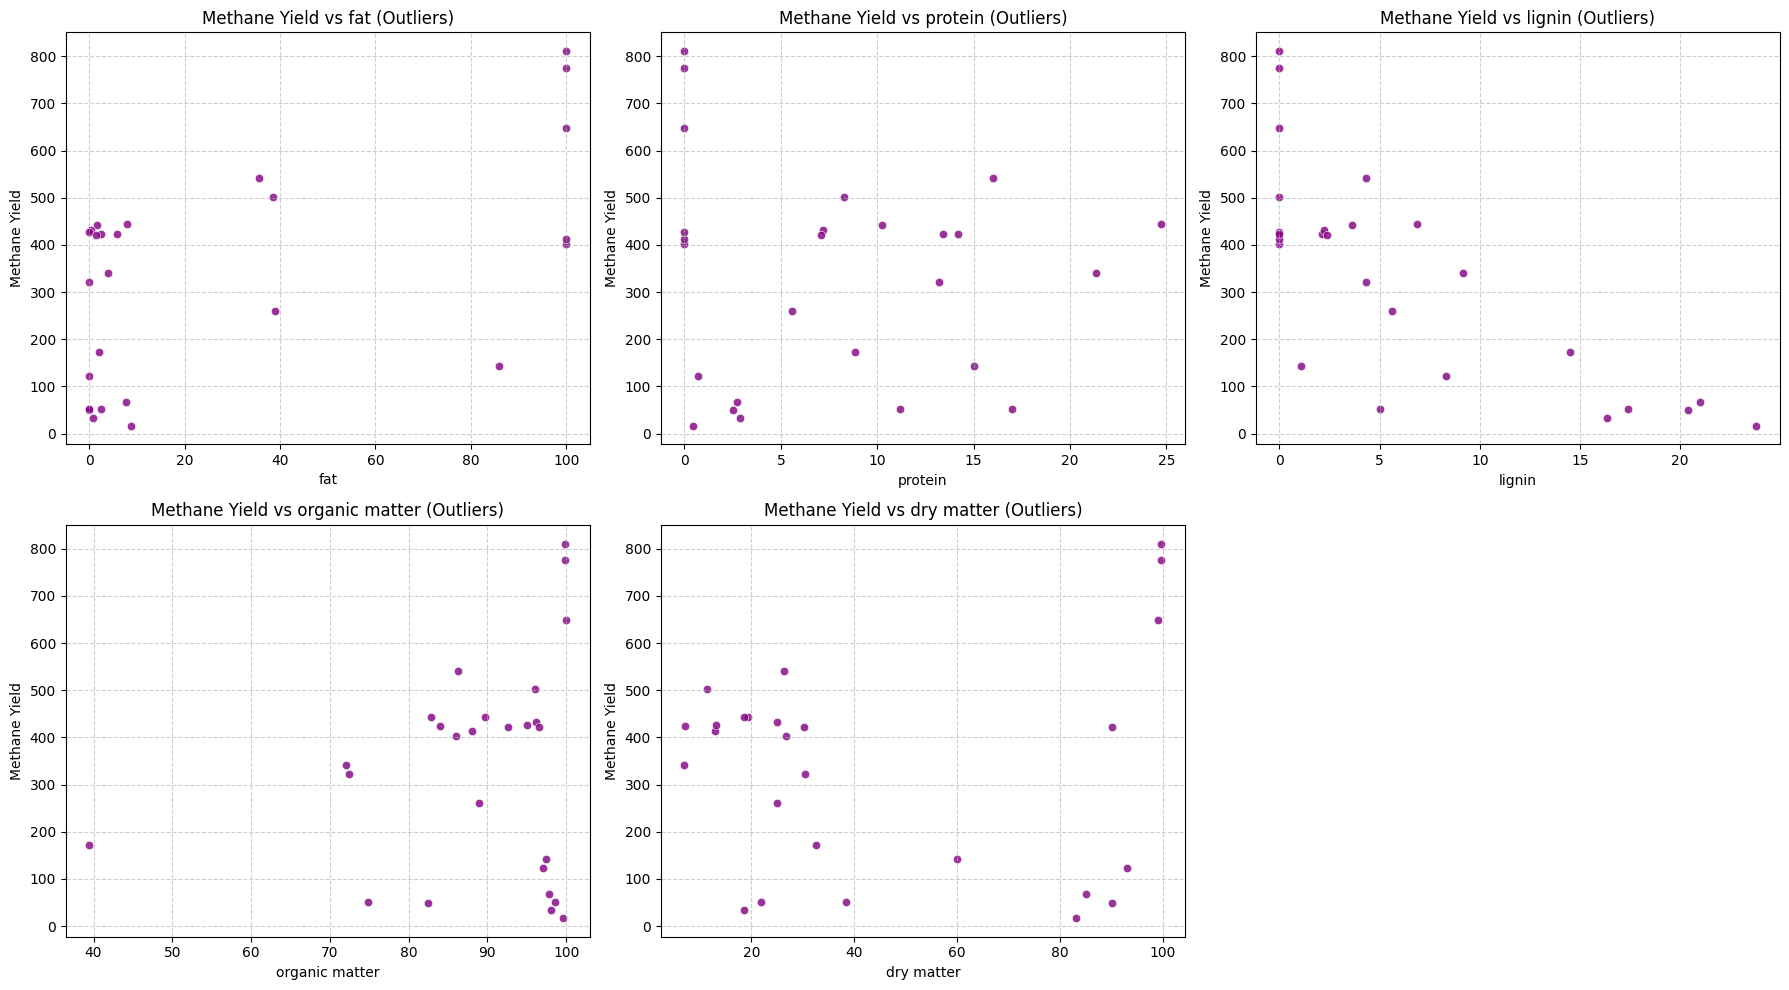

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select numeric columns from the outliers_lof DataFrame
numeric_cols_outliers = outliers_lof.select_dtypes(include=['number']).columns

# Exclude 'Methane yield' itself, and the LOF-specific columns
numeric_cols_for_corr = numeric_cols_outliers.drop(['Methane yield', 'lof_score', 'lof_negative_factor', 'experimental temperature of anaerobic digestion'], errors='ignore')

# Determine the grid size for the subplots
num_cols_per_row = 3
num_rows = math.ceil(len(numeric_cols_for_corr) / num_cols_per_row)

plt.figure(figsize=(18, 5 * num_rows))

for i, col in enumerate(numeric_cols_for_corr):
    plt.subplot(num_rows, num_cols_per_row, i + 1)
    sns.scatterplot(x=outliers_lof[col], y=outliers_lof['Methane yield'], color='purple', alpha=0.8)
    plt.title(f'Methane Yield vs {col} (Outliers)')
    plt.xlabel(col)
    plt.ylabel('Methane Yield')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
print("Descriptive statistics for the 26 LOF outliers:")
display(outliers_lof.describe())

Descriptive statistics for the 26 LOF outliers:


,fat,protein,lignin,organic matter,Methane yield,experimental temperature of anaerobic digestion,dry matter,lof_score,lof_negative_factor
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.0,26.000000
mean,28.599615,7.792452,6.475000,88.913771,335.972846,36.538462,44.800385,-1.0,-2.504336
std,40.312708,7.343216,7.577999,13.278082,226.784191,1.028816,34.251861,0.0,1.599343
min,0.000000,0.000000,0.000000,39.490000,17.017000,35.000000,7.000000,-1.0,-7.467718
25%,0.920000,0.507812,0.000000,84.500000,127.207500,35.500000,18.822500,-1.0,-2.538698
50%,4.745000,7.150000,3.950000,93.786031,407.850000,37.000000,28.475000,-1.0,-1.886826
75%,38.900000,13.350000,8.960000,97.744925,440.215000,37.000000,84.587500,-1.0,-1.586388
max,100.000000,24.730000,23.800000,100.000000,811.000000,39.000000,99.700000,-1.0,-1.526199


### Analysis of LOF Outliers

From the descriptive statistics of the 26 LOF outliers, we can observe several interesting characteristics:

*   **Fat**: The maximum `fat` content for outliers is 100, which is significantly higher than the overall dataset's maximum of 100.00 and average of ~7. This suggests that very high fat content is a strong indicator of an outlier.
*   **Protein**: The protein values vary widely, with a maximum of 15.00, which is higher than average protein, but lower than the overall dataset maximum.
*   **Lignin**: Lignin values in the outliers range from 0 to 23.8, covering a broad spectrum, but tend to be on the lower to medium side compared to the overall dataset's range.
*   **Organic Matter**: Some outliers show lower organic matter (down to 86) compared to the overall dataset's minimum of 39.49, but most are in the high 80s and 90s, with a maximum of 100. This indicates that very low organic matter *or* extremely high organic matter might contribute to outlier status.
*   **Methane Yield**: Outliers include both very high methane yields (up to 811) and very low methane yields (down to 17.017), suggesting that extreme values in methane yield, both high and low, can be characteristics of an outlier.
*   **Dry Matter**: Similar to methane yield, dry matter values in outliers span a wide range, from very low (12.84) to very high (99.70). This indicates that extreme values in dry matter contribute to outlier detection.

In summary, the LOF method identified outliers primarily based on extreme values in features like **fat**, **methane yield**, and **dry matter**. These values are either significantly higher or lower than what is typical for the majority of the dataset, making these entries stand out in their local neighborhoods.

In [ ]:
df_encoded.describe()

,fat,protein,lignin,organic matter,Methane yield,experimental temperature of anaerobic digestion,dry matter,lof_score,lof_negative_factor
count,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000
mean,6.975741,12.709745,6.338254,90.567869,285.146942,37.452381,41.482989,0.862434,-1.159835
std,14.523878,6.908773,4.144800,5.823386,89.560681,1.101774,29.362655,0.506841,0.559220
min,0.000000,0.000000,0.000000,39.490000,17.017000,35.000000,3.700000,-1.000000,-7.467718
25%,1.820000,7.200000,3.500000,89.247500,229.320000,37.000000,20.682500,1.000000,-1.120048
50%,2.700000,12.245000,5.815000,91.140000,293.190000,37.000000,26.455000,1.000000,-1.031398
75%,3.707500,17.682500,8.300000,93.642256,340.722500,37.000000,79.500000,1.000000,-0.994204
max,100.000000,31.030000,28.100000,100.000000,811.000000,40.000000,99.700000,1.000000,-0.952354


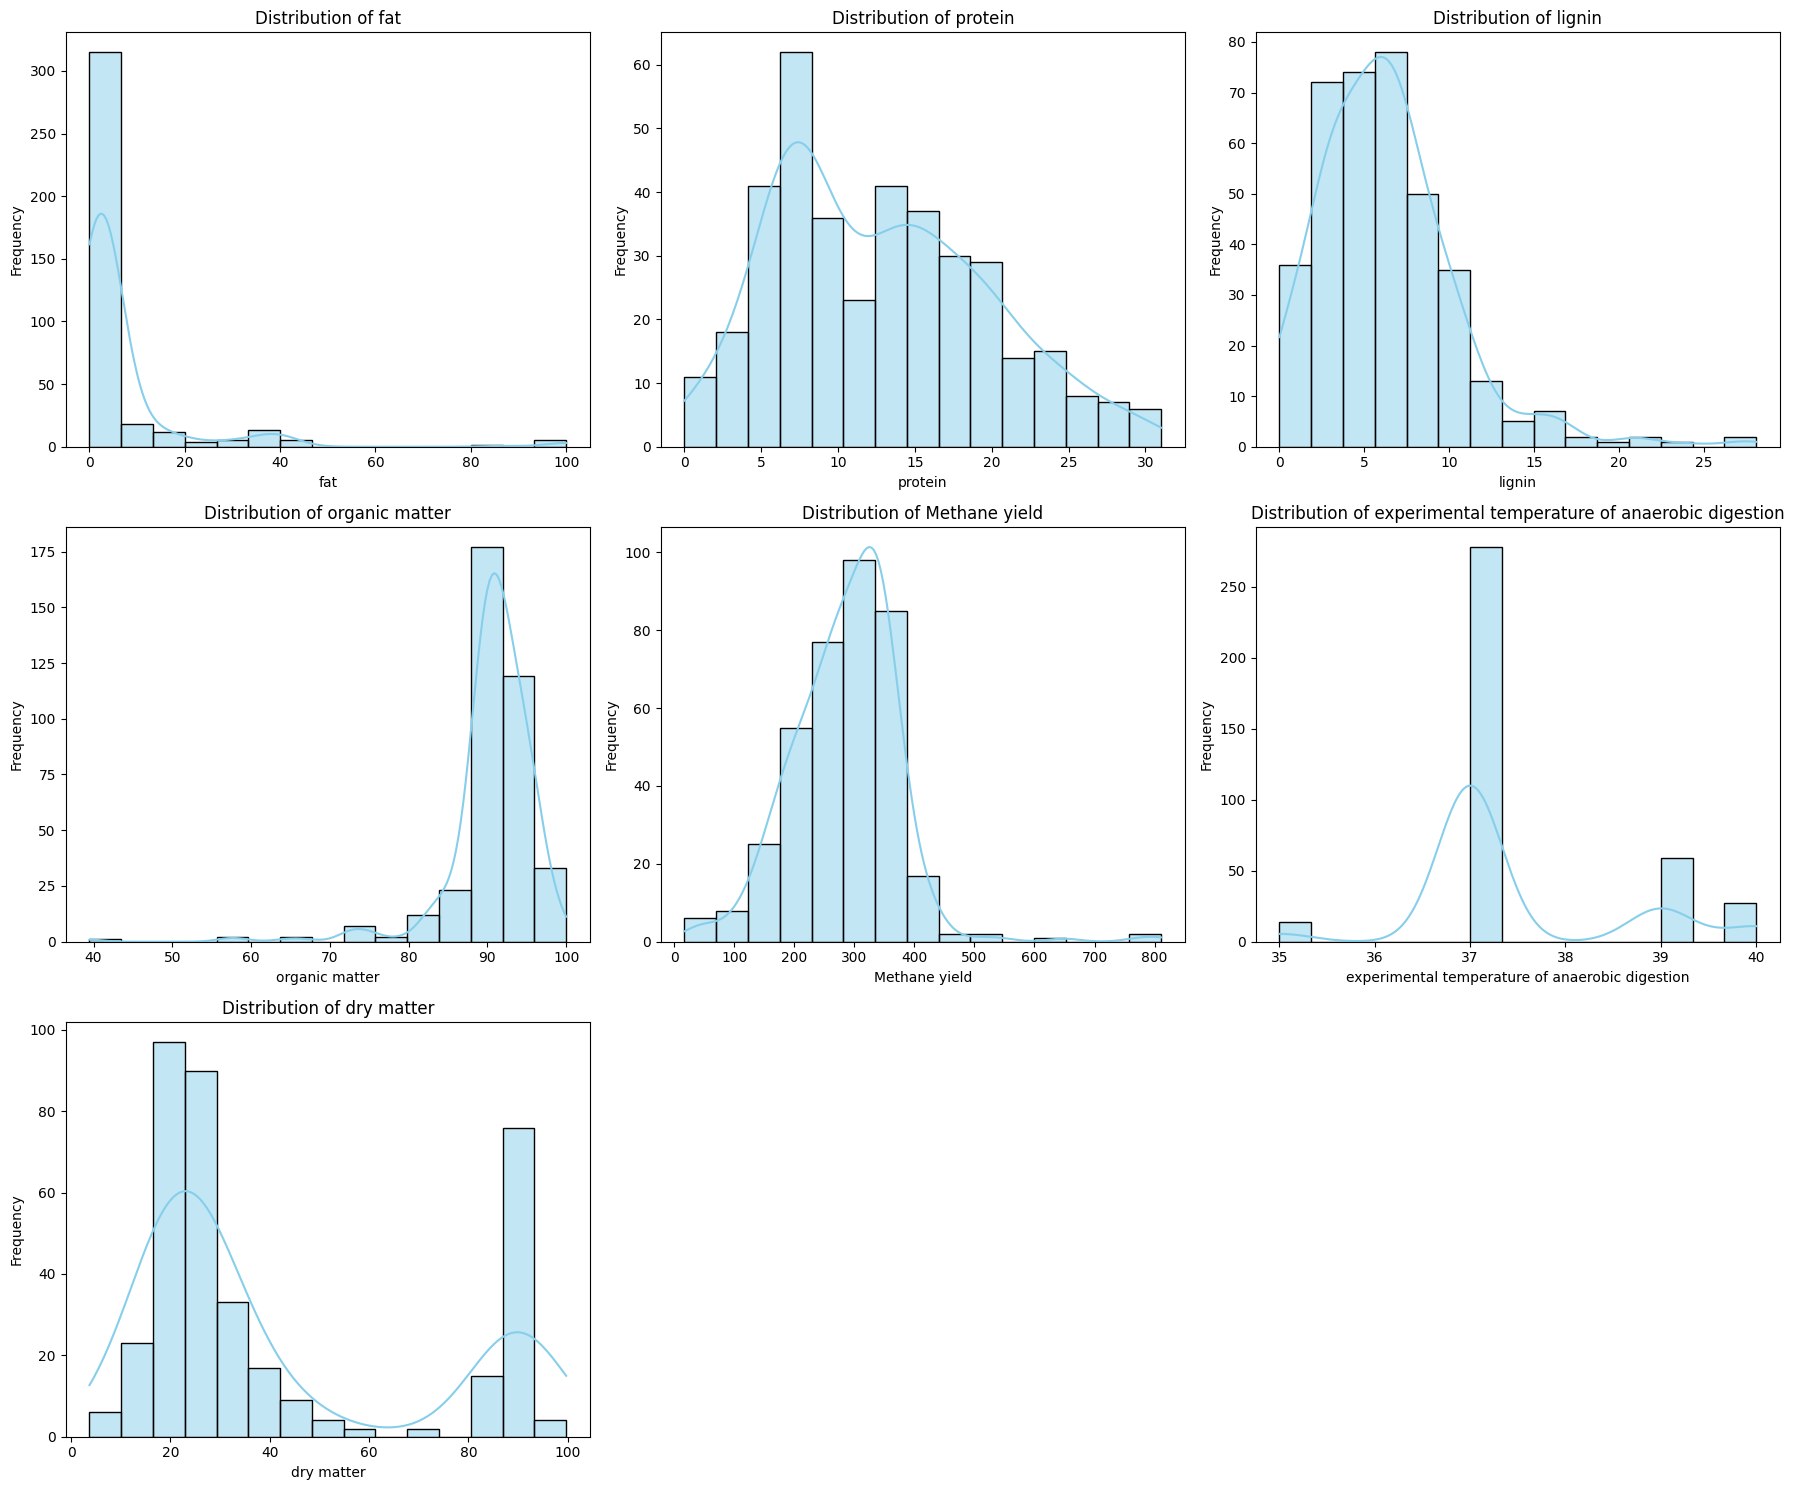

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Get the numeric columns from df_final_cleaned
numeric_cols = df_final_cleaned.select_dtypes(include=['number']).columns

# Determine the grid size for the subplots
num_cols_per_row = 3
num_rows = math.ceil(len(numeric_cols) / num_cols_per_row)

plt.figure(figsize=(18, 5 * num_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(num_rows, num_cols_per_row, i + 1)
    sns.histplot(df_final_cleaned[col].dropna(), kde=True, bins=15, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import boxcox
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# --- Transformations for 'protein' ---
# Log Transformation: using log1p to handle potential zero values
df_encoded['protein_log'] = np.log1p(df_encoded['protein'])

# Box-Cox Transformation: requires positive data. Adding a small constant if min is 0.
# Since df_encoded['protein'].min() is 0, add 1 to make it strictly positive for boxcox.
df_encoded['protein_boxcox'], lambda_protein = boxcox(df_encoded['protein'] + 1)
print(f"Box-Cox lambda for protein: {lambda_protein:.4f}")

# Min-Max Scaling
scaler_protein = MinMaxScaler()
df_encoded['protein_minmax'] = scaler_protein.fit_transform(df_encoded[['protein']])

# --- Transformations for 'Methane yield' ---
# Log Transformation: 'Methane yield' is already strictly positive
df_encoded['methane_yield_log'] = np.log(df_encoded['Methane yield'])

# Box-Cox Transformation: 'Methane yield' is strictly positive
df_encoded['methane_yield_boxcox'], lambda_methane_yield = boxcox(df_encoded['Methane yield'])
print(f"Box-Cox lambda for Methane yield: {lambda_methane_yield:.4f}")

# Min-Max Scaling
scaler_methane = MinMaxScaler()
df_encoded['methane_yield_minmax'] = scaler_methane.fit_transform(df_encoded[['Methane yield']])

print("\nDataFrame head with transformed columns:")
display(df_encoded.head())

print("\nDescriptive statistics for transformed 'protein' columns:")
display(df_encoded[['protein', 'protein_log', 'protein_boxcox', 'protein_minmax']].describe())

print("\nDescriptive statistics for transformed 'Methane yield' columns:")
display(df_encoded[['Methane yield', 'methane_yield_log', 'methane_yield_boxcox', 'methane_yield_minmax']].describe())

Box-Cox lambda for protein: 0.5765
Box-Cox lambda for Methane yield: 0.8257

DataFrame head with transformed columns:


,substrate identification,substrate name,substrate class in database,fat,protein,lignin,organic matter,Methane yield,temperature range,experimental temperature of anaerobic digestion,...,experimental scale_pilot,configuration_semicontinuous,lof_score,lof_negative_factor,protein_log,protein_boxcox,protein_minmax,methane_yield_log,methane_yield_boxcox,methane_yield_minmax
0,Straw,Barley Straw,agricultural,0.8,6.2,9.6,94.3,240.0,mesophilic,40.0,...,False,False,1,-1.021550,1.974081,3.678610,0.199807,5.480639,110.611470,0.280841
1,Straw,Barley Straw,agricultural,0.8,6.2,9.6,94.3,286.0,mesophilic,40.0,...,False,False,1,-1.069446,1.974081,3.678610,0.199807,5.655992,128.033062,0.338777
2,Straw,Barley Straw,agricultural,0.8,6.2,9.6,94.3,339.0,mesophilic,40.0,...,False,False,1,-0.962571,1.974081,3.678610,0.199807,5.826000,147.511112,0.405529
3,Straw,Barley Straw,agricultural,0.8,6.2,9.6,94.3,370.0,mesophilic,40.0,...,False,False,1,-1.110752,1.974081,3.678610,0.199807,5.913503,158.654247,0.444572
4,Straw,Barley Straw,agricultural,0.5,5.2,10.0,94.6,340.0,mesophilic,40.0,...,False,False,1,-1.013984,1.824549,3.231508,0.167580,5.828946,147.873263,0.406788



Descriptive statistics for transformed 'protein' columns:


,protein,protein_log,protein_boxcox,protein_minmax
count,378.000000,378.000000,378.000000,378.000000
mean,12.709745,2.458752,5.846821,0.409595
std,6.908773,0.629361,2.348247,0.222648
min,0.000000,0.000000,0.000000,0.000000
25%,7.200000,2.104134,4.100075,0.232034
50%,12.245000,2.583614,5.957882,0.394618
75%,17.682500,2.927586,7.645061,0.569852
max,31.030000,3.466673,11.063929,1.000000



Descriptive statistics for transformed 'Methane yield' columns:


,Methane yield,methane_yield_log,methane_yield_boxcox,methane_yield_minmax
count,378.000000,378.000000,378.000000,378.000000
mean,285.146942,5.592314,126.752587,0.337702
std,89.560681,0.389507,33.599025,0.112799
min,17.017000,2.834213,11.364324,0.000000
25%,229.320000,5.435115,106.486407,0.267390
50%,293.190000,5.680821,130.710108,0.347832
75%,340.722500,5.831068,148.134802,0.407698
max,811.000000,6.698268,304.401140,1.000000


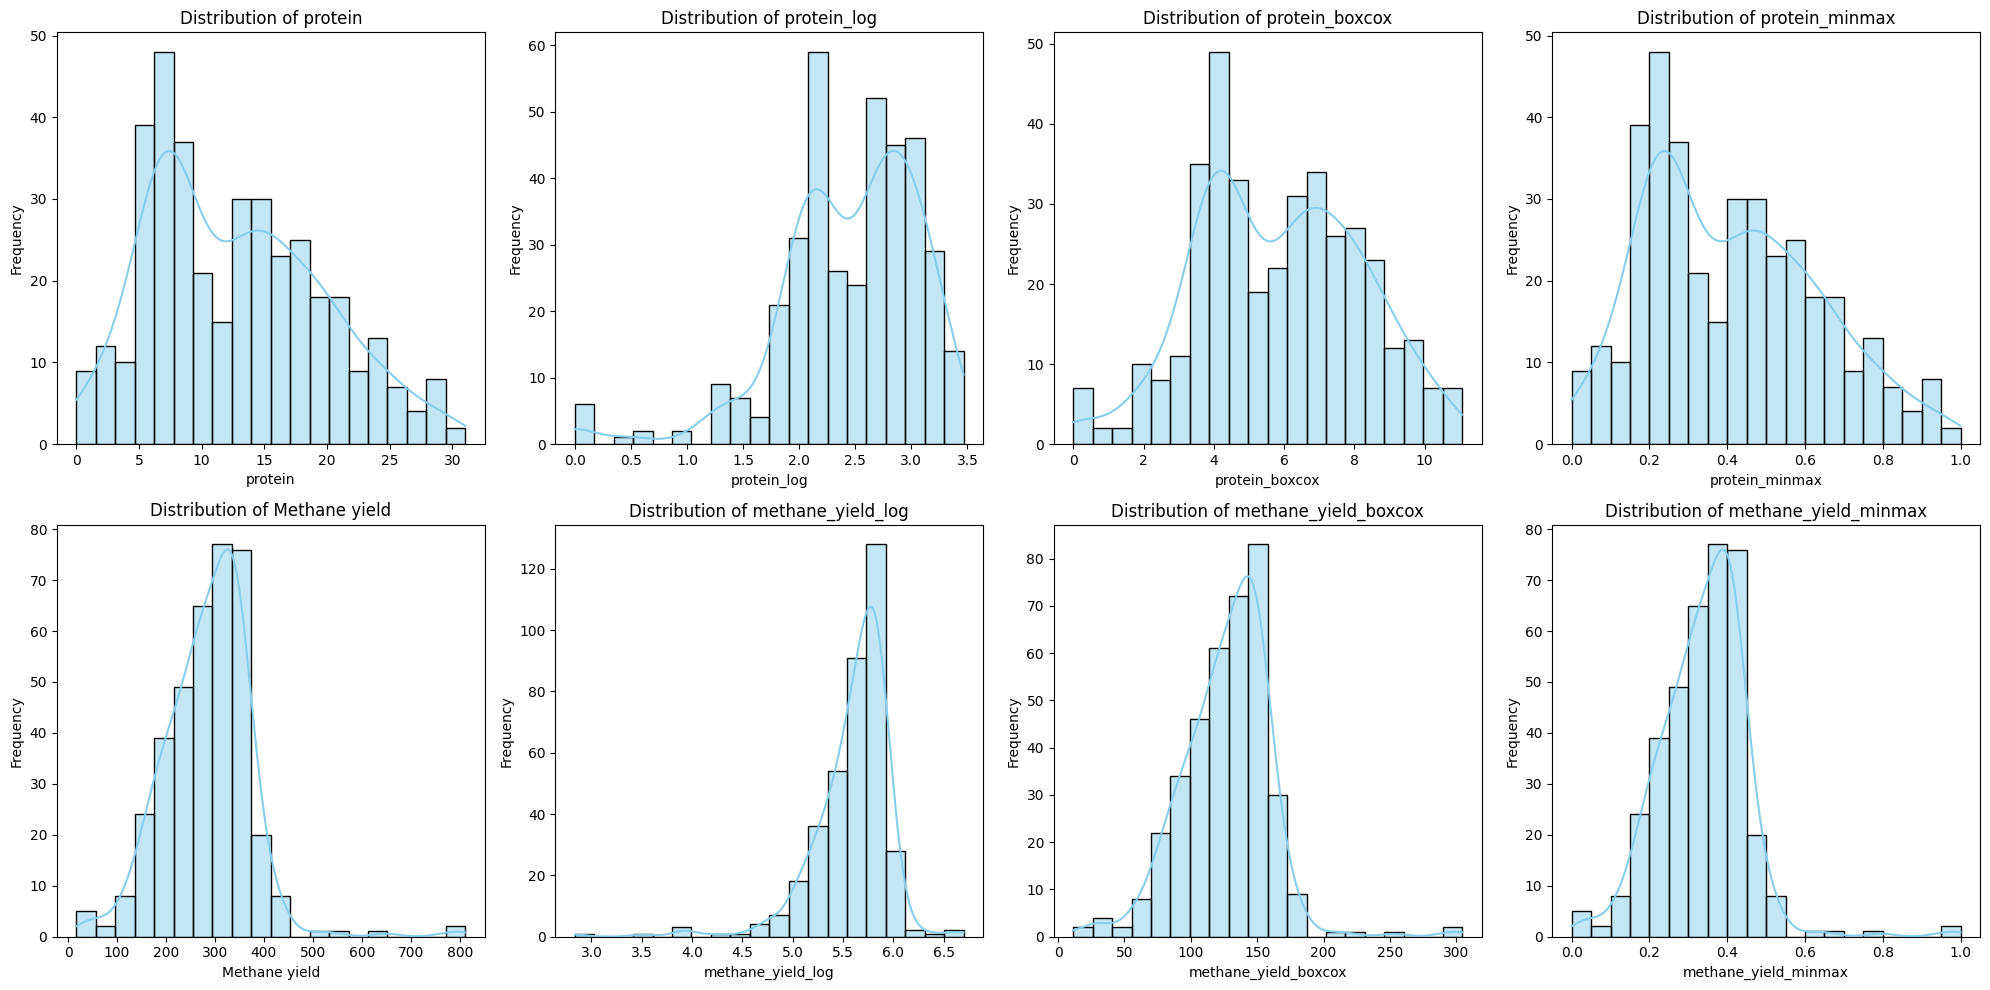

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select the original and transformed columns for plotting
plot_cols = [
    'protein', 'protein_log', 'protein_boxcox', 'protein_minmax',
    'Methane yield', 'methane_yield_log', 'methane_yield_boxcox', 'methane_yield_minmax'
]

# Determine the grid size for the subplots
num_cols_per_row = 4 # 4 plots per row for easier comparison
num_rows = math.ceil(len(plot_cols) / num_cols_per_row)

plt.figure(figsize=(20, 5 * num_rows))

for i, col in enumerate(plot_cols):
    plt.subplot(num_rows, num_cols_per_row, i + 1)
    sns.histplot(df_encoded[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

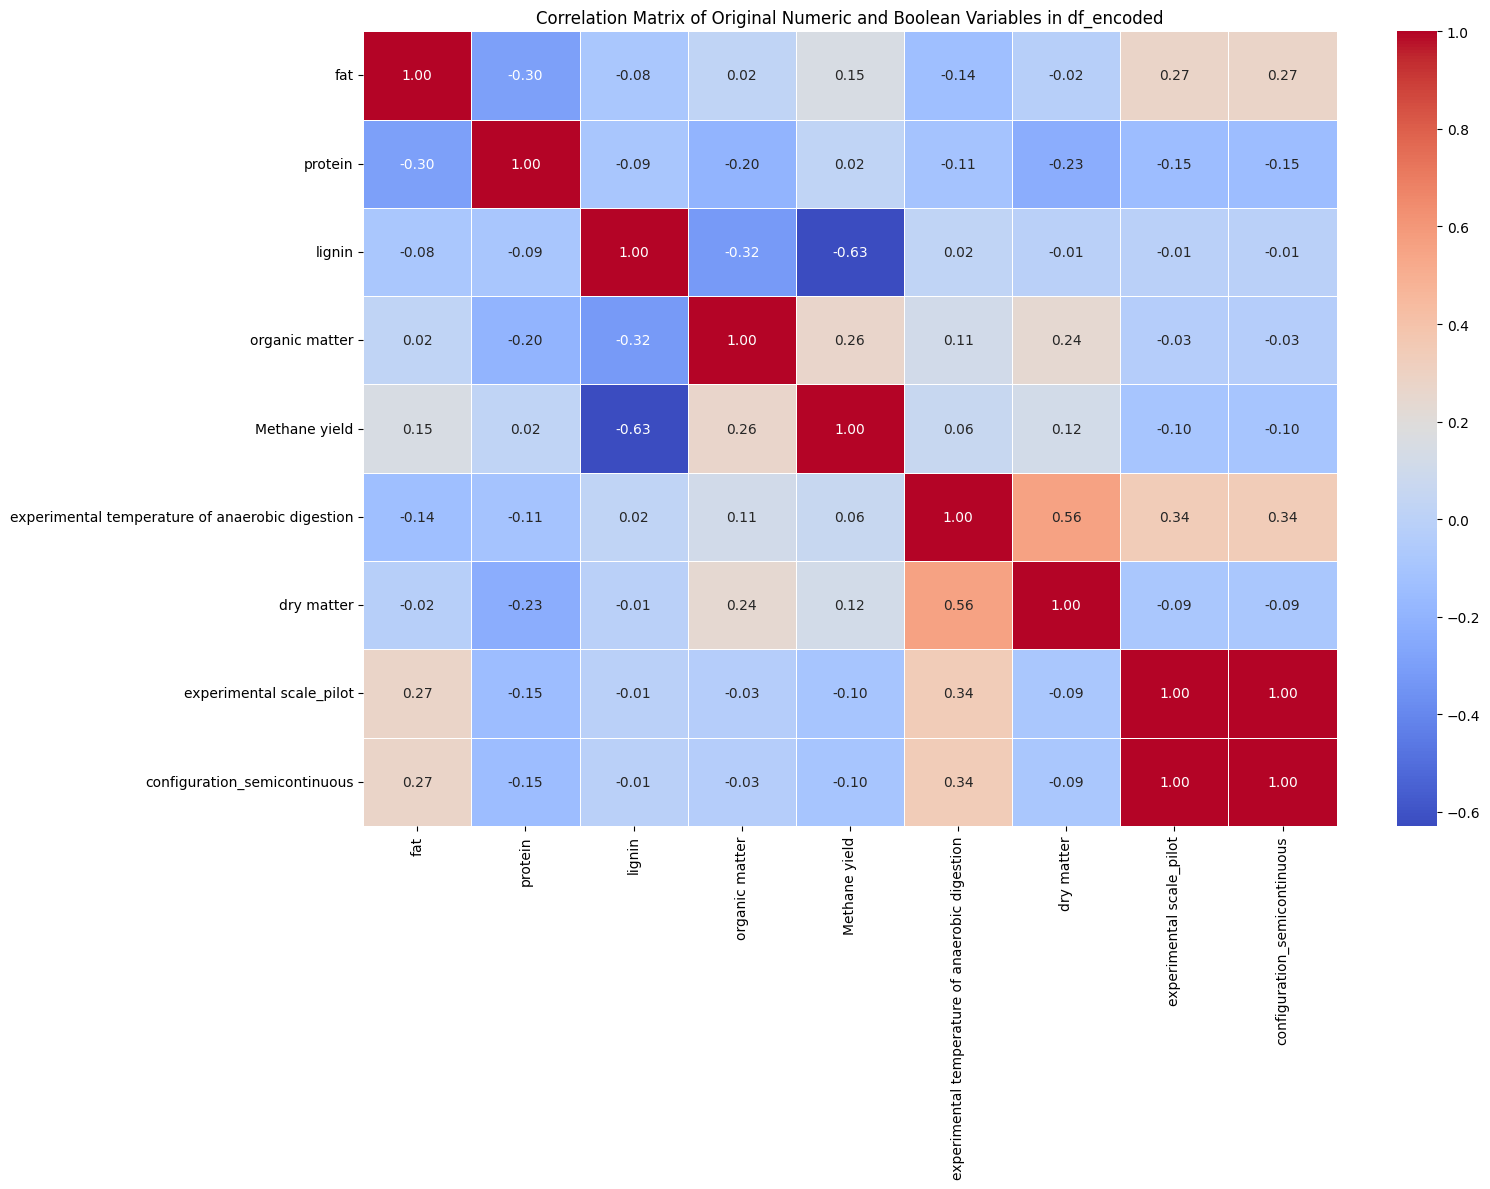

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select all numeric and boolean columns
numeric_and_bool_cols = df_encoded.select_dtypes(include=['number', 'bool'])

# Calculate the correlation matrix
correlation_matrix = numeric_and_bool_cols.corr()

# Plot the correlation matrix heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numeric and Boolean Variables in df_encoded')
plt.tight_layout()
plt.show()

<Figure size 2000x2000 with 0 Axes>

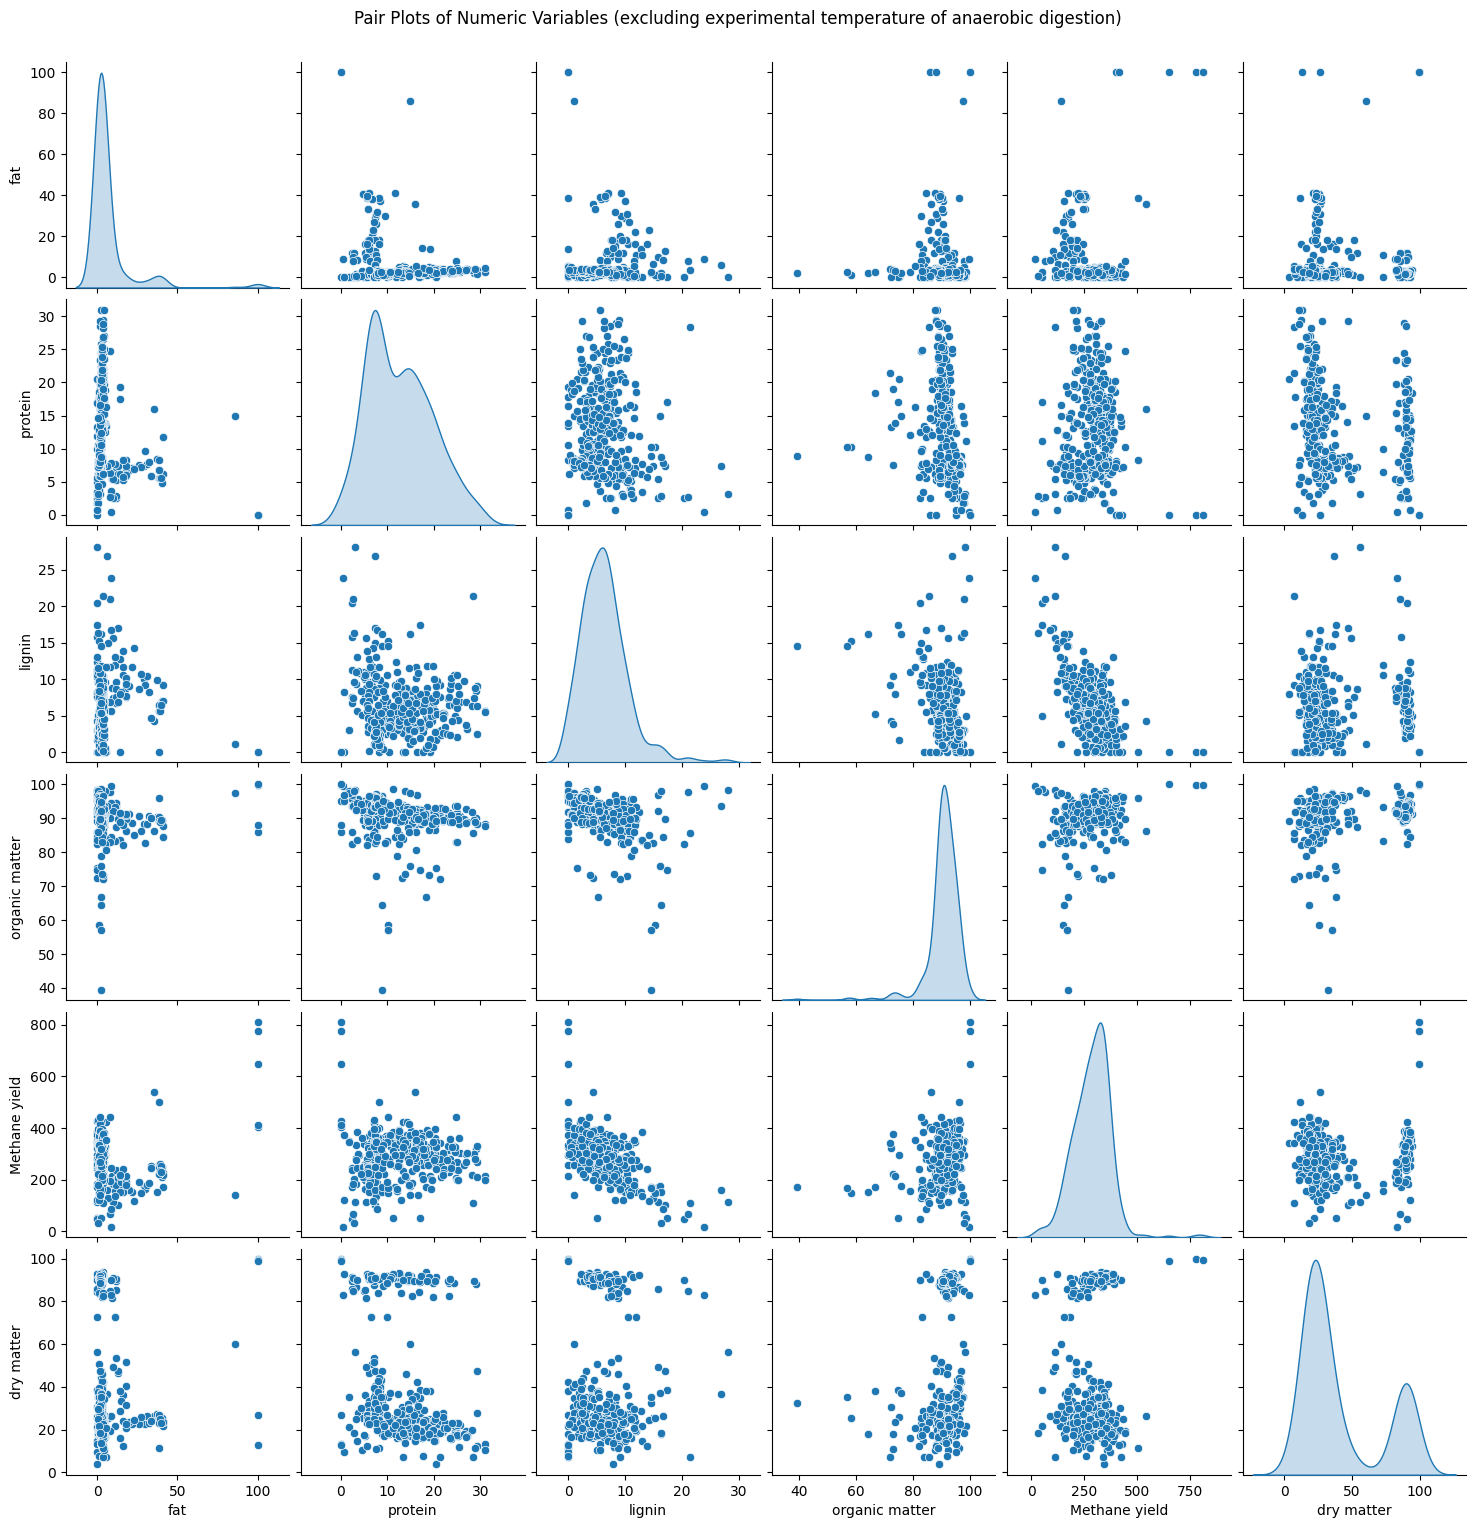

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols_for_pairplot = df_encoded.select_dtypes(include=['number'])

# Exclude transformed columns and LOF scores if they are still present and not desired
columns_to_exclude_from_pairplot = [
    'protein_log', 'protein_boxcox', 'protein_minmax',
    'methane_yield_log', 'methane_yield_boxcox', 'methane_yield_minmax',
    'lof_score', 'lof_negative_factor',
    'experimental temperature of anaerobic digestion' # Exclude this column as requested
]
numeric_cols_for_pairplot = numeric_cols_for_pairplot.drop(columns=columns_to_exclude_from_pairplot, errors='ignore')

plt.figure(figsize=(20, 20)) # Adjust figure size as needed, pairplot creates its own figure
sns.pairplot(numeric_cols_for_pairplot, diag_kind='kde')
plt.suptitle('Pair Plots of Numeric Variables (excluding experimental temperature of anaerobic digestion)', y=1.02) # Adjust title position
plt.show()

In [ ]:
filtered_rows = df_encoded[
    (df_encoded['fat'] > fat_75th_percentile) &
    (df_encoded['lignin'] < lignin_25th_percentile) &
    (df_encoded['organic matter'] > organic_matter_75th_percentile) &
    (df_encoded['Methane yield'] <= methane_yield_75th_percentile)
]

print("Filtered rows based on the specified conditions:")
display(filtered_rows)

Filtered rows based on the specified conditions:


,substrate identification,substrate name,substrate class in database,fat,protein,lignin,organic matter,Methane yield,temperature range,experimental temperature of anaerobic digestion,...,experimental scale_pilot,configuration_semicontinuous,lof_score,lof_negative_factor,protein_log,protein_boxcox,protein_minmax,methane_yield_log,methane_yield_boxcox,methane_yield_minmax
89,corn silage,corn silage,agricultural,5.00,13.8,0.00,98.00,296.10,mesophilic,35.0,...,False,False,1,-0.970660,2.694627,6.466277,0.444731,5.690697,131.790322,0.351497
103,slaughter house waste,fish slaughter waste,industrial,86.01,15.0,1.08,97.47,142.23,mesophilic,37.0,...,False,False,-1,-2.184642,2.772589,6.843277,0.483403,4.957445,71.384875,0.157702
